# Rent Prediction Model — From Raw Listings to a Robust Final Model

This notebook tells the complete modeling story for Swiss apartment cold-rent
prediction. The goal is not only to find the lowest RMSE on one eval split, but
to select a final model that is accurate, stable, and easy to justify.

**Storyline**

1. Build a clean modeling table from raw listing and geo data.
2. Create interpretable features and controlled feature sets.
3. Compare model families under the same train/eval split.
4. Diagnose errors, especially overfitting and the expensive-price segment.
5. Add geography through `geo_cluster` and compare `ALL` vs `ALL+geo`.
6. Select **GradientBoosting with `ALL+geo`** as the final model because it has the best robustness story: the smallest relevant overfitting gap, even if it is slightly less accurate than the most aggressive alternatives.
7. Stress-test the decision with tuning, stacking, KNN features, regularization, a wide-data experiment, and a production-style wrapper.

---

## Phase 1 - Prepare trustworthy data

Before modeling, we make the data consistent, remove only clearly invalid rows,
and create features that have a real-estate interpretation.

## 1. Setup and Reproducibility

The story starts with a reproducible environment. We import all libraries once,
fix the random seed, and standardize plotting. This matters because the whole
notebook is about comparing models fairly: if the split changes every time, the
model ranking would not be trustworthy.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GroupShuffleSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    median_absolute_error, r2_score
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional boosting libraries — the notebook also runs without these.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f'XGBoost available : {HAS_XGB}')
print(f'LightGBM available: {HAS_LGBM}')


XGBoost available : True
LightGBM available: True


In [2]:
# === Uniform plotting style for the whole notebook ===
# Set the style defaults centrally so that every plot
# has the same look afterwards: same font size, colors,
# and axis spines. The design uses a blue-first palette for the
# main marks. Reference lines remain red so they stand out clearly
# from blue bars and scatter points.
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOK_COLORS = {
    'primary':   '#1F77B4',  # clear blue
    'reference': '#D62728',  # red reference / zero / perfect-prediction line
    'secondary': '#4EA3D8',  # light blue for comparison values
    'dark':      '#1F4E79',  # dark blue for train/baseline values
    'teal':      '#2A9D8F',
    'orange':    '#F4A261',
    'purple':    '#6F4EAD',
    'gray':      '#6C757D',
    'neutral':   '#2C3E50',
}

NOTEBOOK_PALETTE = [
    NOTEBOOK_COLORS['primary'],
    NOTEBOOK_COLORS['secondary'],
    NOTEBOOK_COLORS['teal'],
    NOTEBOOK_COLORS['orange'],
    NOTEBOOK_COLORS['purple'],
    NOTEBOOK_COLORS['gray'],
    NOTEBOOK_COLORS['dark'],
    NOTEBOOK_COLORS['neutral'],
]

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette=NOTEBOOK_PALETTE,
    font='DejaVu Sans',
    rc={
        'figure.figsize':   (8.0, 4.8),
        'figure.dpi':       110,
        'savefig.dpi':      150,
        'savefig.bbox':     'tight',
        'axes.titlesize':   12,
        'axes.labelsize':   11,
        'axes.spines.top':   False,
        'axes.spines.right': False,
        'legend.frameon':    False,
        'grid.alpha':        0.35,
    },
)
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=NOTEBOOK_PALETTE)


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG_DIR = Path("../../docs/final-report/fig")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename, fig=None, dpi=220):
    """
    Saves the current matplotlib figure or a given figure into docs/final-report/fig.
    """
    if fig is None:
        fig = plt.gcf()

    output_path = FIG_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


## 2. Load the Modeling Dataset

We begin with `model.csv`, the flat modeling table created from listing data,
listing details, and Swisstopo/GWR information. From this point on, the model
only sees a single DataFrame. Keeping the data flat makes the later pipeline
much easier to reproduce and export.

In [4]:
DATA_PATH = '../external-sources/output_csv/model.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head()


Loaded: 4536 rows × 12 columns


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,34,2,850,44,2043.0,2.0,572.9,2687446.25,1248599.000,1971,1,192.0
1,108,4,1990,107,5656.0,3.0,672.3,2642156.00,1130267.625,1974,34,2000.0
2,97,4,1520,184,12617.0,4.0,439.6,2597233.25,1226600.375,2017,18,367.0
3,23,1,1396,129,18439.0,4.0,430.4,2532786.25,1155625.250,1948,50,731.0
4,76,3,1400,48,717.0,3.0,743.6,2583429.75,1231621.000,2018,17,587.0


## 3. Standardize Column Names

Before doing analysis, we turn mixed source names into one consistent modeling
schema. Scraper fields and register fields use different naming conventions, so
renaming them early avoids confusion later when features, plots, and model
inputs all refer to the same columns.

In [5]:
column_renames = {
    'area_sqm':    'area',
    'rooms':       'rooms',
    'price_cold':  'price',
    'population':  'population',
    'oev_score':   'oev',
    'solar_class': 'solar',
    'elevation_m': 'elevation',
    'lv95_east':   'east',
    'lv95_north':  'north',
    'gbauj':       'year_built',
    'ganzwhg':     'apartments',
    'garea':       'land_area',
}

df = df_raw.rename(columns=column_renames).copy()
print('Columns after rename:', df.columns.tolist())


Columns after rename: ['area', 'rooms', 'price', 'population', 'oev', 'solar', 'elevation', 'east', 'north', 'year_built', 'apartments', 'land_area']


## 4. Data Quality Audit

Before training any model, we check the basic health of the dataset: row count,
missing values, summary statistics, and skewed distributions. This first audit
already shows the main modeling challenge: rents are right-skewed, which means
expensive apartments are harder to predict than typical ones.

In [6]:
print('Shape:', df.shape)
df.info()


Shape: (4536, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4536 entries, 0 to 4535
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        4536 non-null   int64  
 1   rooms       4536 non-null   int64  
 2   price       4536 non-null   int64  
 3   population  4536 non-null   int64  
 4   oev         4536 non-null   float64
 5   solar       4536 non-null   float64
 6   elevation   4536 non-null   float64
 7   east        4536 non-null   float64
 8   north       4536 non-null   float64
 9   year_built  4536 non-null   int64  
 10  apartments  4536 non-null   int64  
 11  land_area   4536 non-null   float64
dtypes: float64(6), int64(6)
memory usage: 425.4 KB


In [7]:
print('Missing values per column:')
print(df.isna().sum())
print()
print('Duplicates (complete rows):', df.duplicated().sum())


Missing values per column:
area          0
rooms         0
price         0
population    0
oev           0
solar         0
elevation     0
east          0
north         0
year_built    0
apartments    0
land_area     0
dtype: int64

Duplicates (complete rows): 325


In [8]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
area,4536.0,7.752403e+01,32.103016,1.00,5.600000e+01,76.000,9.500000e+01,324.0
rooms,4536.0,2.802249e+00,1.102830,1.00,2.000000e+00,3.000,4.000000e+00,15.0
price,4536.0,1.816199e+03,732.310694,130.00,1.345000e+03,1680.000,2.130000e+03,7700.0
population,4536.0,1.090999e+02,82.577927,3.00,4.900000e+01,90.000,1.440000e+02,602.0
oev,4536.0,9.986069e+03,14960.307365,0.00,1.800000e+03,4911.500,1.154900e+04,135157.0
solar,4536.0,3.092372e+00,1.015459,1.00,2.000000e+00,3.000,4.000000e+00,5.0
elevation,4536.0,4.624071e+02,158.817656,197.70,3.915000e+02,435.600,5.170000e+02,1570.7
east,4536.0,2.640999e+06,69270.961596,2494493.75,2.596506e+06,2645843.625,2.690937e+06,2818550.0
north,4536.0,1.218718e+06,52055.722323,1076962.00,1.178774e+06,1244662.000,1.258623e+06,1286728.5
year_built,4536.0,1.968925e+03,55.641365,1187.00,1.953000e+03,1974.000,2.010000e+03,2026.0


## 5. Duplicates and Domain Outliers

The next step is to remove obvious noise without over-cleaning the dataset.
Some listings appear multiple times, so exact duplicates are removed. For
outliers, the rules stay conservative: we only filter clearly unrealistic size
and rent values. Everything else remains in the data so that the model still
learns from genuine market variation.

In [9]:
TARGET_COL = 'price'

# Preliminary feature list for the duplicate check — finalized cleanly in the feature-set section.
_features_for_dup_check = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

print('Total duplicates          :', df.duplicated().sum())
print('Feature+target duplicates :', df.duplicated(subset=_features_for_dup_check + [TARGET_COL]).sum())
print('Feature-only duplicates   :', df.duplicated(subset=_features_for_dup_check).sum())


Total duplicates          : 325
Feature+target duplicates : 325
Feature-only duplicates   : 562


In [10]:
# price_per_sqm for analysis ONLY — explicitly not used as a feature.
df['price_per_sqm'] = df['price'] / df['area']

print('Top 20 by price_per_sqm (very expensive per m²):')
df.sort_values('price_per_sqm', ascending=False).head(20)


Top 20 by price_per_sqm (very expensive per m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
3337,1,6,2500,13,225.0,2.0,668.5,2539457.75,1171911.250,2007,1,266.0,2500.000000
3213,1,4,2050,3,916.0,2.0,450.7,2536852.00,1183189.125,1895,1,70.0,2050.000000
427,1,3,1650,64,1691.0,5.0,625.3,2558554.00,1145940.125,1970,12,298.0,1650.000000
2019,1,3,1370,143,2077.0,4.0,450.7,2561697.25,1185393.375,1965,27,402.0,1370.000000
3137,1,3,1370,205,2077.0,1.0,450.9,2561732.00,1185383.000,1910,2,157.0,1370.000000
3068,1,2,1250,123,30274.0,5.0,413.9,2533764.75,1154087.375,1962,54,561.0,1250.000000
422,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
2746,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
71,1,2,860,95,12866.0,1.0,671.2,2746200.00,1254470.125,1918,9,1117.0,860.000000
2904,18,1,2500,231,96716.0,4.0,412.8,2681354.50,1247688.625,1909,41,208.0,138.888889


In [11]:
print('Bottom 20 by price_per_sqm (very cheap per m²):')
df.sort_values('price_per_sqm', ascending=True).head(20)


Bottom 20 by price_per_sqm (very cheap per m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
1444,105,4,200,177,15495.0,3.0,257.4,2611991.75,1267862.875,1891,2,258.0,1.904762
3543,110,3,258,147,1251.0,2.0,443.5,2676175.25,1214992.000,2005,3,101.0,2.345455
411,84,4,245,125,539.0,3.0,565.2,2722051.75,1258093.875,1964,9,313.0,2.916667
553,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
86,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
188,40,2,130,46,12414.0,3.0,727.3,2746243.75,1255577.375,1964,1,159.0,3.250000
2422,300,4,1225,94,2430.0,3.0,634.2,2736227.75,1253378.625,1964,12,454.0,4.083333
4477,324,4,1900,53,11140.0,3.0,716.4,2746006.25,1254976.625,1918,3,189.0,5.864198
3179,159,4,1170,213,2495.0,3.0,280.9,2614673.25,1264600.125,1980,9,586.0,7.358491
4380,183,4,1460,57,2858.0,2.0,353.6,2664160.50,1270660.750,1900,3,126.0,7.978142


In [12]:
# Suspicious rows
print('area == 1:', (df['area'] == 1).sum())
print('area  < 10:', (df['area'] < 10).sum())
print('price < 300:', (df['price'] < 300).sum())
print('rooms > 10:', (df['rooms'] > 10).sum())
print('rooms < 1 :', (df['rooms'] < 1).sum())


area == 1: 9
area  < 10: 10
price < 300: 4
rooms > 10: 1
rooms < 1 : 0


**Filter rule — domain-based justification**

- `area >= 10`: apartments below 10 m² are hardly realistic in Switzerland and are usually data errors.
- `price >= 300`: cold rents below 300 CHF are very unusual and are usually entry errors.

These are not hidden assumptions. They are documented here because every filter
changes the training distribution. If the domain assumptions change, this is the
place to adjust them.

In [13]:
n_before = len(df)

df_clean = df[
    (df['area']  >= 10) &
    (df['price'] >= 300)
].copy()

n_after_filter = len(df_clean)

df_model = df_clean.drop_duplicates().copy()
n_after_dedup = len(df_model)

print(f'Before                         : {n_before}')
print(f'After outlier filter           : {n_after_filter}  (removed: {n_before - n_after_filter})')
print(f'After drop_duplicates          : {n_after_dedup}  (removed: {n_after_filter - n_after_dedup})')


Before                         : 4536
After outlier filter           : 4522  (removed: 14)
After drop_duplicates          : 4198  (removed: 324)


## 6. Feature Engineering: Turning Raw Fields into Signals

Now we turn raw fields into more meaningful predictors. Instead of expecting the
model to infer everything from raw columns, we add a few interpretable signals:

- `building_age = REFERENCE_YEAR - year_built`: age is easier to interpret than construction year.
- `area_per_room = area / rooms`: captures whether an apartment has large rooms or many small rooms.
- `land_area_per_apartment = garea / ganzwhg`: a rough proxy for building density.

The goal is not to create many features, but to add features that have a clear
real-estate interpretation.

In [14]:
REFERENCE_YEAR = 2026  # Reference year for building_age

if 'year_built' in df_model.columns:
    df_model['building_age'] = REFERENCE_YEAR - df_model['year_built']

df_model['area_per_room'] = np.where(
    df_model['rooms'] > 0,
    df_model['area'] / df_model['rooms'],
    np.nan
)

df_model['land_area_per_apartment'] = np.where(
    df_model['apartments'] > 0,
    df_model['land_area'] / df_model['apartments'],
    np.nan
)

df_model[['building_age', 'area_per_room', 'land_area_per_apartment']].describe()


,building_age,area_per_room,land_area_per_apartment
count,4198.000000,4198.000000,4198.000000
mean,57.479514,28.730035,49.834520
std,56.225773,10.031427,118.529662
min,0.000000,2.666667,2.314286
25%,16.000000,24.000000,20.111111
50%,52.000000,27.250000,29.226496
75%,73.750000,31.250000,43.600000
max,839.000000,224.000000,2735.000000


## 7. Define Feature Sets as Experiments

Instead of testing one fixed input table, we compare several feature sets. This
turns feature selection into a controlled experiment: small baseline, all raw
features, and engineered features. Defining them centrally also keeps the later
model-comparison code clean and reproducible.

In [15]:
TARGET_COL = 'price'

FEATURES_SMALL = [
    'area', 'rooms', 'land_area', 'population', 'oev'
]

FEATURES_ALL = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

FEATURES_ENGINEERED = FEATURES_ALL + [
    'building_age', 'area_per_room', 'land_area_per_apartment'
]

# Validation: do the columns exist?
for name, cols in [
    ('FEATURES_SMALL',      FEATURES_SMALL),
    ('FEATURES_ALL',        FEATURES_ALL),
    ('FEATURES_ENGINEERED', FEATURES_ENGINEERED),
]:
    missing = [c for c in cols if c not in df_model.columns]
    assert not missing, f'{name}: missing columns {missing}'
    print(f'{name:22s}: {len(cols)} Features OK')


FEATURES_SMALL        : 5 Features OK
FEATURES_ALL          : 11 Features OK
FEATURES_ENGINEERED   : 14 Features OK


## 8. Clean Train/Eval Split

We split the data into 80% train and 20% eval using a fixed `random_state=42`.
From this point on, the eval set is treated as unseen data. Helper models such
as KMeans and KNN are fitted only on the train side and then applied to eval, so
the reported eval metrics remain meaningful.

In [16]:
# Analysis-only columns must never appear as features
_analysis_only_cols = ['price_per_sqm']

df_for_split = df_model.drop(columns=_analysis_only_cols, errors='ignore').copy()

# Remove rows without complete feature data in the broadest set
# so that the split remains deterministically reproducible.
df_for_split = df_for_split.dropna(subset=FEATURES_ENGINEERED + [TARGET_COL])

train_df, eval_df = train_test_split(
    df_for_split,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df)} rows')
print(f'Eval : {len(eval_df)} rows')
print(f'Total: {len(df_for_split)} rows ({len(train_df)/len(df_for_split):.1%} train)')


Train: 3358 rows
Eval : 840 rows
Total: 4198 rows (80.0% train)


---

## Phase 2 — Establish a fair baseline

With the data prepared, the next question is which model family works best under
the same split and the same metrics.

## 9. Model Pipelines

The candidate models are wrapped in `sklearn.Pipeline` objects. This gives every
model the preprocessing it needs while keeping the evaluation code identical.
Tree-based models can work directly with the feature values, while Ridge gets a
`StandardScaler` because coordinate values would otherwise dominate the linear
model.

In [17]:
def make_models():
    """Creates a fresh model collection for each call (no state)."""
    models = {
        'Dummy (median)': DummyRegressor(strategy='median'),

        'Ridge (scaled)': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),

        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        ),

        'GradientBoosting': GradientBoostingRegressor(
            random_state=RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return models


print('Available models:', list(make_models().keys()))


Available models: ['Dummy (median)', 'Ridge (scaled)', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 10. Baseline Model Comparison

We now establish the first benchmark: same train set, same eval set, same
metrics. MAE, RMSE, R², and the train/eval gap answer two different questions:
how accurate is the model, and how much did it overfit the training data?

At this stage, the goal is not yet to pick the final model. The goal is to learn
which model families are promising and which ones are too weak for the problem.

In [18]:
def rmse(y_true, y_pred):
    """Robust to older sklearn versions without squared=False."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_models(
    train_df, eval_df, feature_cols, target_col, models,
):
    """Trains all models on the same split and collects metrics.

    Returns
    -------
    results_df : pd.DataFrame    sorted metrics table
    fitted     : dict[str, model] trained models
    cache      : dict[str, dict]  predictions on train and eval
    """
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_eval  = eval_df[feature_cols]
    y_eval  = eval_df[target_col]

    records = []
    fitted  = {}
    cache   = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_eval  = model.predict(X_eval)

        records.append({
            'Model':       name,
            'MAE Train':   mean_absolute_error(y_train, y_pred_train),
            'MAE Eval':    mean_absolute_error(y_eval,  y_pred_eval),
            'MedAE Train': median_absolute_error(y_train, y_pred_train),
            'MedAE Eval':  median_absolute_error(y_eval,  y_pred_eval),
            'RMSE Train':  rmse(y_train, y_pred_train),
            'RMSE Eval':   rmse(y_eval,  y_pred_eval),
            'R² Train':    r2_score(y_train, y_pred_train),
            'R² Eval':     r2_score(y_eval,  y_pred_eval),
        })
        fitted[name] = model
        cache[name]  = {'train': y_pred_train, 'eval': y_pred_eval}

    results_df = pd.DataFrame(records)
    results_df['Overfitting Gap'] = results_df['RMSE Eval'] - results_df['RMSE Train']
    results_df = results_df.sort_values('RMSE Eval').reset_index(drop=True)

    return results_df, fitted, cache


In [19]:
# 10a) FEATURES_SMALL
results_small, fitted_small, cache_small = evaluate_models(
    train_df, eval_df, FEATURES_SMALL, TARGET_COL, make_models(),
)
print('--- FEATURES_SMALL ---')
results_small


--- FEATURES_SMALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192
1,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747
2,XGBoost,167.714706,362.225189,124.102356,244.799988,233.193933,541.650516,0.896341,0.527990,308.456583
3,GradientBoosting,332.012868,376.288654,247.013617,277.079735,460.124522,542.887909,0.596424,0.525831,82.763388
4,Ridge (scaled),383.142755,393.807267,285.322273,278.133150,542.901204,567.472456,0.438156,0.481914,24.571252
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [20]:
# 10b) FEATURES_ALL
results_all, fitted_all, cache_all = evaluate_models(
    train_df, eval_df, FEATURES_ALL, TARGET_COL, make_models(),
)
print('--- FEATURES_ALL ---')
results_all


--- FEATURES_ALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699
1,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918
2,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570
3,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148
4,Ridge (scaled),379.737388,389.217176,283.736956,269.897717,538.944813,560.534174,0.446315,0.494505,21.589361
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [21]:
# 10c) FEATURES_ENGINEERED
results_eng, fitted_eng, cache_eng = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL, make_models(),
)
print('--- FEATURES_ENGINEERED ---')
results_eng


--- FEATURES_ENGINEERED ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718
1,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039
2,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284
3,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542
4,Ridge (scaled),379.527962,389.102715,282.930009,268.688985,538.819616,560.072923,0.446572,0.495337,21.253306
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


## 11. First Visual Check: Train vs Eval

A train-vs-eval bar plot makes the model comparison easier to read. When train
RMSE is much lower than eval RMSE, the model has likely learned patterns that do
not generalize. This visual check prepares the main decision rule used later:
robustness matters, not only raw eval accuracy.

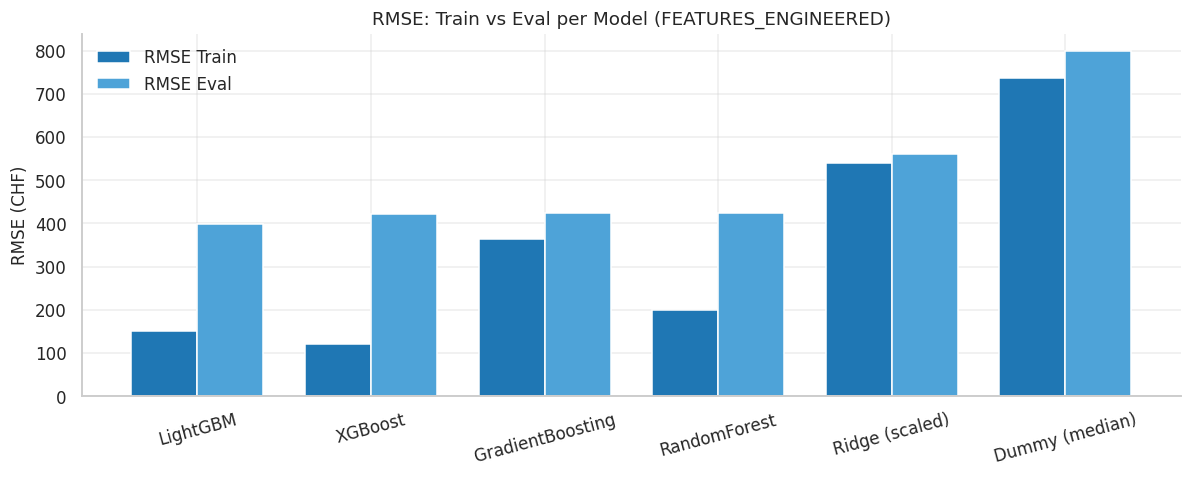

In [22]:
# We use FEATURES_ENGINEERED as the main run, but the function is generic.
main_results = results_eng
main_fitted  = fitted_eng
main_cache   = cache_eng
main_features = FEATURES_ENGINEERED

models_sorted = main_results['Model'].tolist()
x_pos = np.arange(len(models_sorted))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x_pos - width/2, main_results['RMSE Train'], width, label='RMSE Train')
ax.bar(x_pos + width/2, main_results['RMSE Eval'],  width, label='RMSE Eval')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval per Model (FEATURES_ENGINEERED)')
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
save_fig("rmse_train_eval.png", fig)


Saved figure: ../../docs/final-report/fig/rmse_train_eval.png


## 12. Overfitting Diagnosis

Here the overfitting discussion becomes explicit. Each model receives a simple
diagnosis based on the difference between train RMSE and eval RMSE. This is the
first step toward the final argument: a model with slightly higher eval RMSE can
still be preferable if it has a much healthier generalization gap.

In [24]:
def diagnose_overfitting(row):
    train_rmse = row['RMSE Train']
    eval_rmse  = row['RMSE Eval']
    r2_eval    = row['R² Eval']

    gap_ratio = eval_rmse / train_rmse if train_rmse > 0 else np.inf

    if gap_ratio > 1.5 and r2_eval > 0:
        return 'Possible overfitting'
    if r2_eval < 0.3:
        return 'Weak generalization / possible underfitting'
    if gap_ratio <= 1.25 and r2_eval >= 0.6:
        return 'Good generalization'
    return 'Check manually'


diag = main_results[['Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']].copy()
diag['Diagnose'] = main_results.apply(diagnose_overfitting, axis=1)
diag


,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Diagnose
0,LightGBM,150.286423,399.166141,0.743658,248.879718,Possible overfitting
1,XGBoost,121.598850,420.806889,0.715109,299.208039,Possible overfitting
2,GradientBoosting,364.777231,424.709516,0.709801,59.932284,Good generalization
3,RandomForest,198.916167,424.910709,0.709526,225.994542,Possible overfitting
4,Ridge (scaled),538.819616,560.072923,0.495337,21.253306,Check manually
5,Dummy (median),737.368884,799.089038,-0.027313,61.720154,Weak generalization / possible underfitting


## 13. Cross-Validation for Stability

A single train/eval split can be lucky or unlucky. Five-fold cross-validation on
the training data gives a second view of stability. The CV standard deviation is
important because a model that performs inconsistently across folds is risky,
even if it looks strong on one eval split.

In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_scores(train_df, feature_cols, target_col, models, cv):
    X = train_df[feature_cols]
    y = train_df[target_col]

    records = []
    for name, model in models.items():
        cv_r2  = cross_val_score(model, X, y, cv=cv, scoring='r2')
        cv_mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        records.append({
            'Model':       name,
            'CV R² mean':  cv_r2.mean(),
            'CV R² std':   cv_r2.std(),
            'CV RMSE mean': np.sqrt(cv_mse).mean(),
        })
    return pd.DataFrame(records).sort_values('CV R² mean', ascending=False).reset_index(drop=True)


cv_results = cv_scores(train_df, main_features, TARGET_COL, make_models(), cv)
cv_results


,Model,CV R² mean,CV R² std,CV RMSE mean
0,LightGBM,0.673731,0.009397,413.357575
1,XGBoost,0.665411,0.014220,418.608616
2,RandomForest,0.644675,0.020143,431.284596
3,GradientBoosting,0.635606,0.019850,436.590827
4,Ridge (scaled),0.439460,0.016385,541.744142
5,Dummy (median),-0.037457,0.010889,737.255590


## 14. Prediction Quality: Actual vs Predicted

After the benchmark, we look at what the predictions actually look like. The
actual-vs-predicted plot shows whether the model follows the diagonal, while the
residual plots reveal systematic errors. This is where the main weakness becomes
visible: expensive apartments are often harder to estimate.

Best model by RMSE Eval: LightGBM


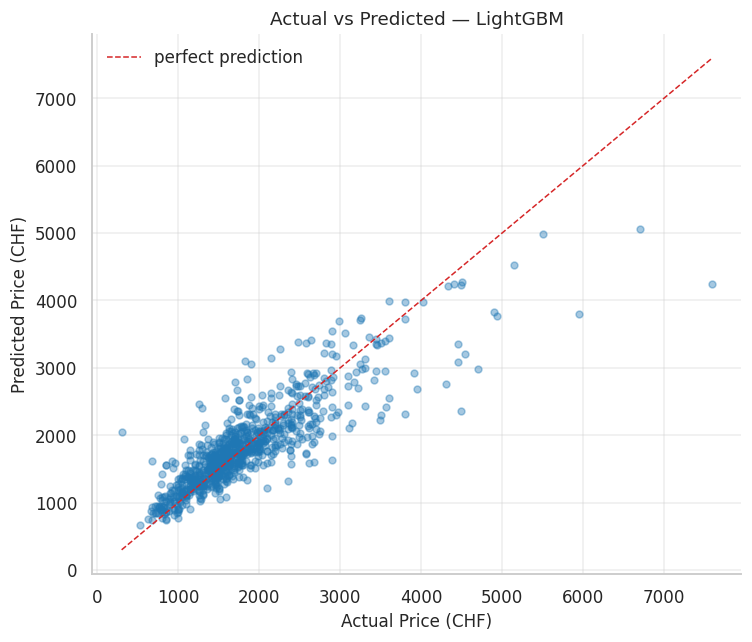

In [26]:
best_name  = main_results.iloc[0]['Model']
best_model = main_fitted[best_name]
y_eval     = eval_df[TARGET_COL]
y_pred     = main_cache[best_name]['eval']

print(f'Best model by RMSE Eval: {best_name}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_eval, y_pred, alpha=0.4, s=20)
lo = float(min(y_eval.min(), y_pred.min()))
hi = float(max(y_eval.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1, label='perfect prediction')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
save_fig("actual_vs_predicted.png", fig)


Saved figure: ../../docs/final-report/fig/actual_vs_predicted.png


## 15. Residual Analysis

This section zooms in on the residuals. The histogram, residual-vs-predicted
plot, and distribution statistics help answer whether the model errors are
roughly symmetric or whether there are patterns left in the data. The right tail
of rents creates a funnel-shaped error pattern, which explains why high-price
segments need special attention.

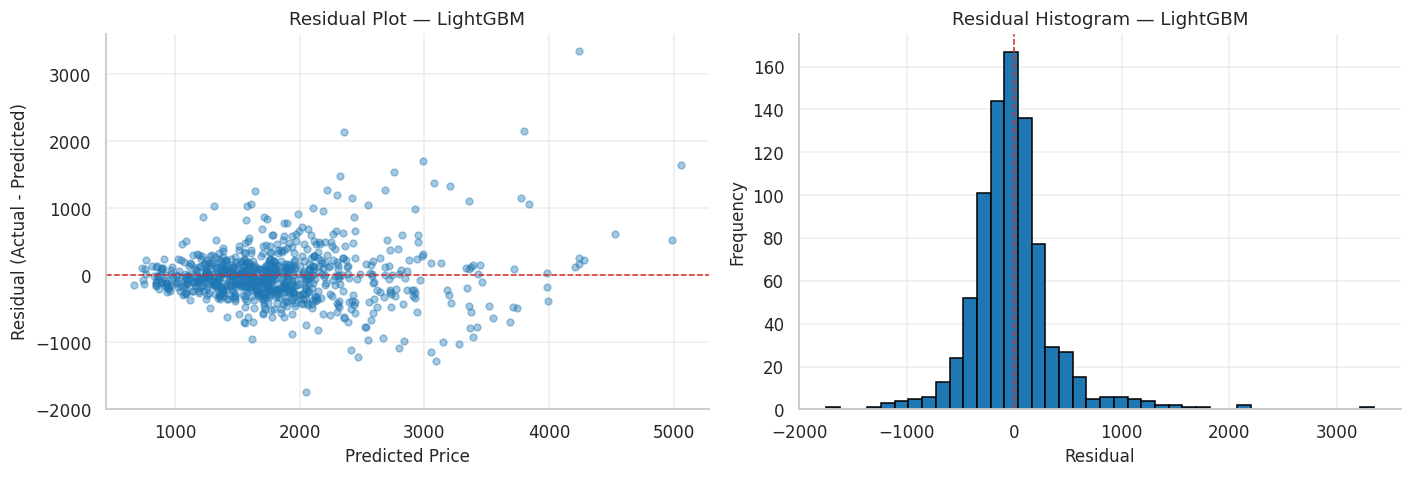

Residual statistics:
count     840.000000
mean      -11.777749
std       399.230054
min     -1747.436976
25%      -216.738138
50%       -38.067641
75%       136.692419
max      3348.764303
Name: price, dtype: float64


In [28]:
residuals = y_eval - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scatter: Predicted vs Residuals
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0].axhline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residual Plot — {best_name}')

# Histogram
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Histogram — {best_name}')

plt.tight_layout()
plt.show()

print('Residual statistics:')
print(residuals.describe())


In [29]:
save_fig("residuals.png", fig)


Saved figure: ../../docs/final-report/fig/residuals.png


## 16. Where the Model Fails: Price Segments

Average metrics hide important differences between cheap, medium, and expensive
apartments. By splitting the eval set into price groups, we see where the model
is reliable and where it struggles. The expensive segment has much larger errors,
which points to missing qualitative features such as floor, view, condition, or
interior standard.

In [30]:
eval_results = pd.DataFrame({
    'actual':    y_eval.reset_index(drop=True),
    'predicted': pd.Series(y_pred).reset_index(drop=True),
})
eval_results['error']     = eval_results['actual'] - eval_results['predicted']
eval_results['abs_error'] = eval_results['error'].abs()

eval_results['price_band'] = pd.qcut(
    eval_results['actual'], q=4,
    labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
    duplicates='drop',
)

(
    eval_results
    .groupby('price_band')['abs_error']
    .agg(['count', 'mean', 'median', 'max'])
    .round(1)
)


,count,mean,median,max
price_band,,,,
cheap,211,215.8,150.4,1747.4
medium_low,212,176.1,143.0,970.4
medium_high,207,221.0,158.1,1276.0
expensive,210,445.3,311.5,3348.8


## 17. First Interpretation: Feature Importance

Before adding more complexity, we inspect which features the tree models rely on.
This first feature-importance check gives a quick sense of whether the model is
using plausible real-estate signals. A deeper multi-method importance comparison
is kept for the later stress-test section.

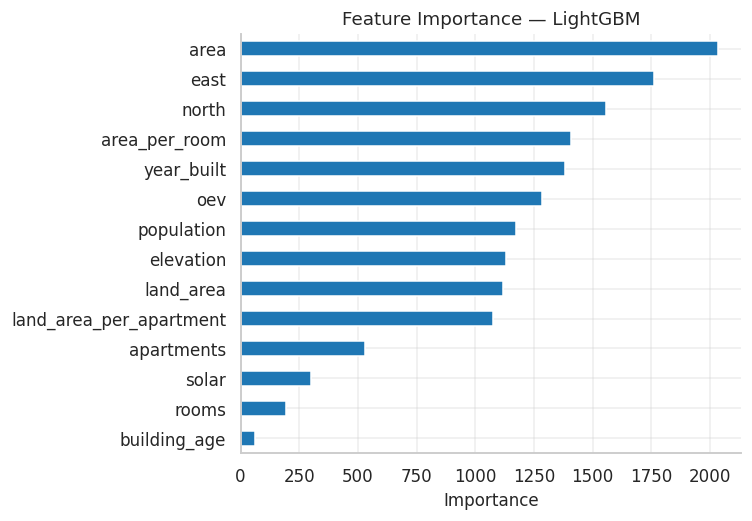

area                       2032
east                       1760
north                      1555
area_per_room              1409
year_built                 1384
oev                        1284
population                 1173
elevation                  1129
land_area                  1117
land_area_per_apartment    1074
apartments                  529
solar                       300
rooms                       194
building_age                 60
dtype: int32

In [31]:
def show_feature_importance(model, feature_cols, X_eval, y_eval, top_n=15):
    # 1) Tree/boosting models
    importances = getattr(model, 'feature_importances_', None)

    # 2) Pipeline → last step
    if importances is None and isinstance(model, Pipeline):
        last = model.steps[-1][1]
        importances = getattr(last, 'feature_importances_', None)
        if importances is None and hasattr(last, 'coef_'):
            importances = np.abs(last.coef_)

    if importances is None:
        # 3) Permutation importance as fallback
        result = permutation_importance(
            model, X_eval, y_eval,
            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
        )
        importances = result.importances_mean

    fi = (
        pd.Series(importances, index=feature_cols)
        .sort_values(ascending=True)
        .tail(top_n)
    )
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(fi))))
    fi.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi.iloc[::-1]


fi = show_feature_importance(
    best_model, main_features,
    eval_df[main_features], eval_df[TARGET_COL],
)
fi


---

## Phase 3 — Move from accuracy to robustness

A single RMSE ranking is not enough. From here on, the model choice is judged by
both predictive accuracy and the train/eval gap.

## 18. Decision Principle: Accuracy Is Not Enough

If we only sorted by eval RMSE, the notebook would end here with the most
accurate model on one split. But that would be too narrow for a final model
choice.

For this project, the final model should be both accurate and defensible. That
means the overfitting gap becomes a key selection criterion. The table below is
therefore kept as a preliminary RMSE benchmark, not as the final decision.

In [32]:
compare_runs = (
    pd.concat([
        results_small.assign(FeatureSet='SMALL'),
        results_all.assign(FeatureSet='ALL'),
        results_eng.assign(FeatureSet='ENGINEERED'),
    ])
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)

preliminary_best_run = compare_runs.iloc[0]
best_run = preliminary_best_run  # kept for backward compatibility in earlier analysis cells
print(
    f'Preliminary best by RMSE Eval: FeatureSet={preliminary_best_run["FeatureSet"]}, '
    f'Model={preliminary_best_run["Model"]}, RMSE Eval={preliminary_best_run["RMSE Eval"]:.1f}'
)
compare_runs.head(10)


Preliminary best by RMSE Eval: FeatureSet=ENGINEERED, Model=LightGBM, RMSE Eval=399.2


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,FeatureSet
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718,ENGINEERED
1,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699,ALL
2,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918,ALL
3,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570,ALL
4,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039,ENGINEERED
5,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284,ENGINEERED
6,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542,ENGINEERED
7,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148,ALL
8,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192,SMALL
9,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747,SMALL


In [33]:
# Mapping FeatureSet -> feature list / fitted-model dictionary
_feature_set_lookup = {
    'SMALL':      (FEATURES_SMALL,      fitted_small),
    'ALL':        (FEATURES_ALL,        fitted_all),
    'ENGINEERED': (FEATURES_ENGINEERED, fitted_eng),
}
best_feature_cols, best_fitted_pool = _feature_set_lookup[best_run['FeatureSet']]
best_model_final = best_fitted_pool[best_run['Model']]

print(f'Preliminary model: {best_run["Model"]}  |  Features: {best_run["FeatureSet"]}  ({len(best_feature_cols)} columns)')
print('Used features in the preliminary model:')
print(best_feature_cols)


Preliminary model: LightGBM  |  Features: ENGINEERED  (14 columns)
Used features in the preliminary model:
['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'population', 'oev', 'solar', 'building_age', 'area_per_room', 'land_area_per_apartment']


---

## Phase 4 — Add geography and make the final decision

Location is central to rent prediction. This phase tests whether explicit geo
clusters improve the model and leads to the final GradientBoosting + `ALL+geo`
choice.

## 19. Geography as a Price Signal

Location is one of the strongest rent drivers, so the next part of the story is
geographical. We inspect the spatial distribution, build KMeans clusters from
LV95 coordinates, and compare models with and without a discrete `geo_cluster`
feature.

The important methodological rule stays the same: KMeans is fitted only on
`train_df`; `eval_df` only receives cluster assignments through `predict`. This
keeps the geo feature useful without leaking information from the eval set.

### 19.1 Check Geo Columns

In [34]:
GEO_COLS      = ['east', 'north']
ELEVATION_COL = 'elevation'

geo_cols_available = [c for c in GEO_COLS if c in df_for_split.columns]
has_full_geo       = len(geo_cols_available) == len(GEO_COLS)
has_elevation      = ELEVATION_COL in df_for_split.columns

print(f'Geo columns available: {geo_cols_available}')
print(f'Elevation available : {has_elevation}')
print(f'Complete geo data: {has_full_geo}')


Geo columns available: ['east', 'north']
Elevation available : True
Complete geo data: True


### 19.2 Geo Exploratory Analysis

In [35]:
if has_full_geo:
    desc_cols = list(geo_cols_available)
    if has_elevation:
        desc_cols += [ELEVATION_COL]
    desc_cols += [TARGET_COL]
    print('Description of geo and price columns:')
    display(df_for_split[desc_cols].describe().T)
else:
    print('Geo EDA skipped — east/north are missing.')


Description of geo and price columns:


,count,mean,std,min,25%,50%,75%,max
east,4198.0,2.642086e+06,68867.424033,2494493.75,2.601377e+06,2648703.75,2.691348e+06,2818550.0
north,4198.0,1.219829e+06,51645.740197,1076962.00,1.181577e+06,1245427.75,1.258914e+06,1286728.5
elevation,4198.0,4.611092e+02,159.029291,197.70,3.902750e+02,434.85,5.131000e+02,1570.7
price,4198.0,1.826667e+03,737.658329,300.00,1.350000e+03,1685.00,2.145750e+03,7700.0


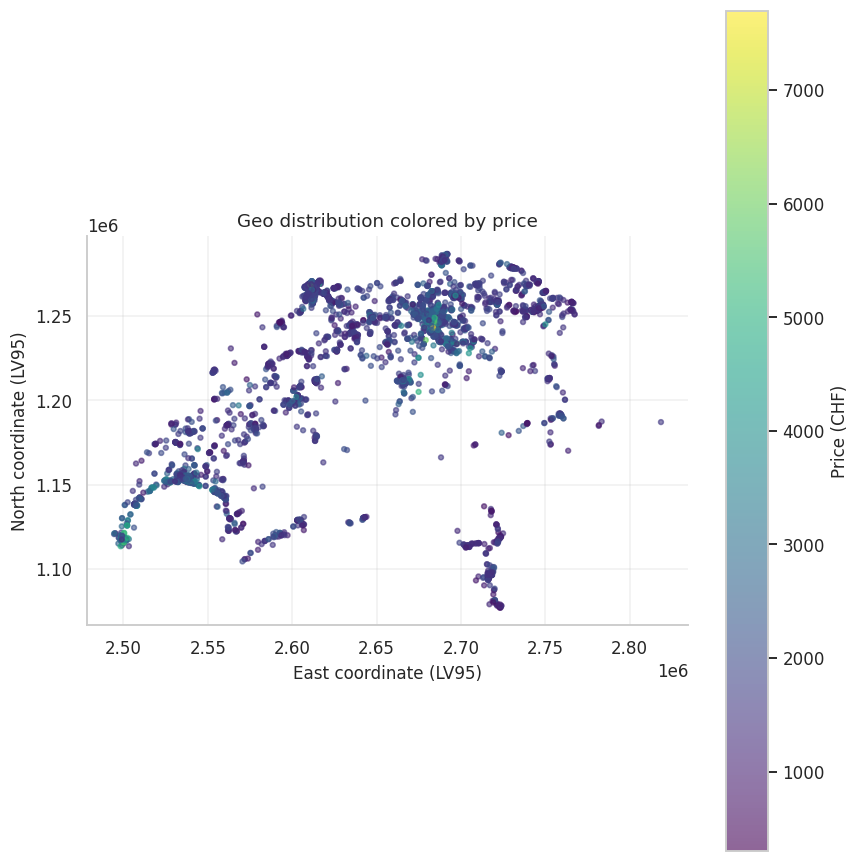

In [36]:
if has_full_geo:
    fig, ax = plt.subplots(figsize=(8, 8))  # square aspect ratio

    sc = ax.scatter(
        df_for_split['east'],
        df_for_split['north'],
        c=df_for_split[TARGET_COL],
        cmap='viridis',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price (CHF)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')

    ax.grid(True, alpha=0.3)

    # IMPORTANT: true square display
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


In [37]:
save_fig("geo_price_map.png", fig)


Saved figure: ../../docs/final-report/fig/geo_price_map.png


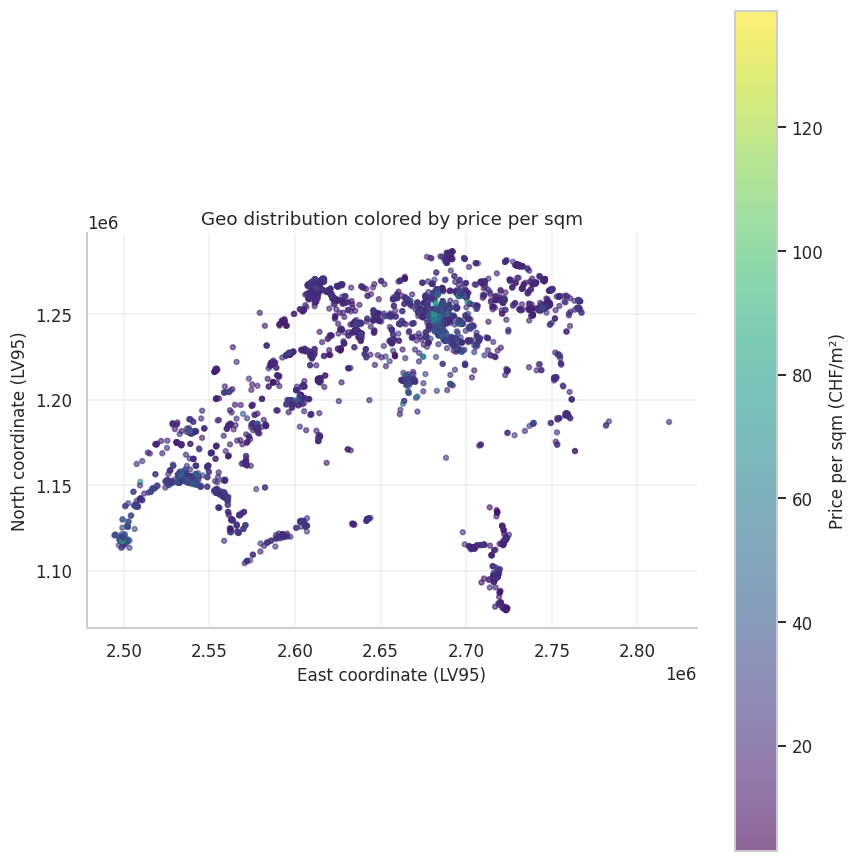

In [38]:
if has_full_geo and 'price_per_sqm' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(8, 8))  # square aspect ratio

    sc = ax.scatter(
        df_clean['east'],
        df_clean['north'],
        c=df_clean['price_per_sqm'],
        cmap='viridis',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price per sqm (CHF/m²)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price per sqm')

    ax.grid(True, alpha=0.3)

    # IMPORTANT: true square display
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()
else:
    print('Skipped: price_per_sqm is not available or geo columns are missing.')


### 19.3 KMeans Geo Clustering

The clusterer runs inside a pipeline with `StandardScaler`, because LV95 east
and north coordinates have large absolute values. For each candidate number of
clusters, we test whether adding `geo_cluster` improves eval RMSE. This turns the
geography idea into a measurable feature-engineering experiment.

In [39]:
from sklearn.cluster import KMeans

GEO_CLUSTER_COLS_2D = ['east', 'north']

if has_full_geo:
    cluster_counts = [4, 6, 8, 10, 12, 15]

    fast_models = {
        'RandomForest_fast': RandomForestRegressor(
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2,
        ),
    }

    cluster_search = []
    cluster_pipes  = {}

    for k in cluster_counts:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)),
        ])
        pipe.fit(train_df[GEO_CLUSTER_COLS_2D])
        cluster_pipes[k] = pipe

        tr = train_df.assign(geo_cluster=pipe.predict(train_df[GEO_CLUSTER_COLS_2D]))
        ev = eval_df.assign(geo_cluster=pipe.predict(eval_df[GEO_CLUSTER_COLS_2D]))

        res, _, _ = evaluate_models(
            tr, ev, FEATURES_ALL + ['geo_cluster'], TARGET_COL, fast_models,
        )
        cluster_search.append({
            'k':         k,
            'RMSE Eval': res.iloc[0]['RMSE Eval'],
            'R² Eval':   res.iloc[0]['R² Eval'],
        })

    cluster_k_df = (
        pd.DataFrame(cluster_search)
          .sort_values('RMSE Eval')
          .reset_index(drop=True)
    )
    print('Cluster-count comparison (RandomForest, FEATURES_ALL + geo_cluster):')
    display(cluster_k_df)

    best_k = int(cluster_k_df.iloc[0]['k'])
    print(f'\n→ Best k on eval: {best_k}')
else:
    best_k = None
    print('Clustering skipped — geo columns are missing.')


Cluster-count comparison (RandomForest, FEATURES_ALL + geo_cluster):


,k,RMSE Eval,R² Eval
0,8,413.287666,0.725200
1,6,414.882764,0.723074
2,15,415.582661,0.722139
3,12,416.639230,0.720725
4,4,417.715879,0.719279
5,10,418.653774,0.718017



→ Best k on eval: 8


### 19.4 Visualize Geo Clusters and Cluster-Level Prices

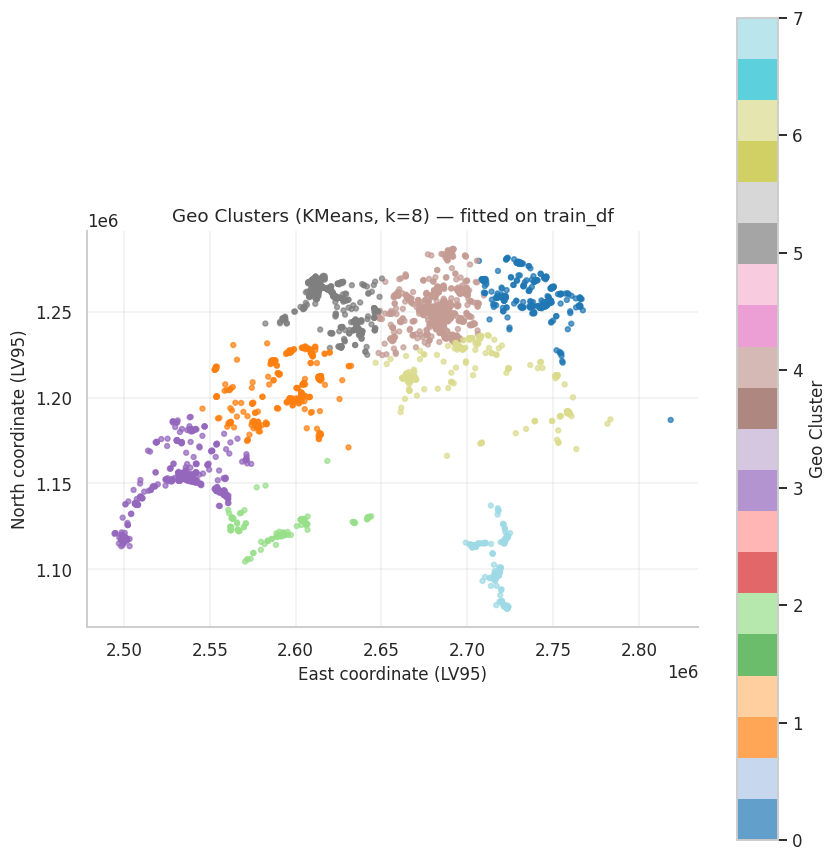

Price statistics per geo cluster (train):


,count,mean,median,std
geo_cluster,,,,
4,894,2159.0,2029.0,786.0
3,565,2028.0,1800.0,876.0
6,237,1924.0,1830.0,680.0
5,716,1627.0,1572.0,528.0
2,102,1602.0,1500.0,597.0
1,293,1583.0,1530.0,460.0
0,384,1511.0,1450.0,492.0
7,167,1408.0,1330.0,466.0


In [40]:
if has_full_geo and best_k is not None:
    geo_pipe_2d = cluster_pipes[best_k]

    train_df_geo = train_df.copy()
    eval_df_geo  = eval_df.copy()

    train_df_geo['geo_cluster'] = geo_pipe_2d.predict(train_df[GEO_CLUSTER_COLS_2D])
    eval_df_geo['geo_cluster']  = geo_pipe_2d.predict(eval_df[GEO_CLUSTER_COLS_2D])

    fig, ax = plt.subplots(figsize=(8, 8))  # square aspect ratio

    sc = ax.scatter(
        train_df_geo['east'],
        train_df_geo['north'],
        c=train_df_geo['geo_cluster'],
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Geo Cluster')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'Geo Clusters (KMeans, k={best_k}) — fitted on train_df')

    ax.grid(True, alpha=0.3)

    # IMPORTANT: true metric display
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    cluster_stats = (
        train_df_geo.groupby('geo_cluster')[TARGET_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .round(0)
        .sort_values('mean', ascending=False)
    )

    print('Price statistics per geo cluster (train):')
    display(cluster_stats)


### 19.5 Compare Models With and Without Geo

We now compare the original feature sets with geo-enhanced variants:

1. `FEATURES_SMALL`
2. `FEATURES_ALL`
3. `FEATURES_ALL + ['geo_cluster']` (`ALL+geo`)
4. `FEATURES_ENGINEERED`
5. `FEATURES_ENGINEERED + ['geo_cluster']`

The table is sorted by eval RMSE for readability, but the final decision also
uses the overfitting gap. This is the key trade-off: the lowest RMSE is not
automatically the most robust model.

In [41]:
if has_full_geo and best_k is not None:
    feature_sets_geo = {
        'SMALL':          FEATURES_SMALL,
        'ALL':            FEATURES_ALL,
        'ALL+geo':        FEATURES_ALL + ['geo_cluster'],
        'ENGINEERED':     FEATURES_ENGINEERED,
        'ENGINEERED+geo': FEATURES_ENGINEERED + ['geo_cluster'],
    }

    geo_runs = []
    for set_name, feats in feature_sets_geo.items():
        # Validation: are all columns present in train_df_geo / eval_df_geo?
        missing = [c for c in feats if c not in train_df_geo.columns]
        if missing:
            print(f'Skipped {set_name}: missing {missing}')
            continue

        results, _, _ = evaluate_models(
            train_df_geo, eval_df_geo, feats, TARGET_COL, make_models(),
        )
        results = results.assign(
            FeatureSet=set_name,
            n_geo_clusters=best_k if 'geo' in set_name else 0,
            geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_2D) if 'geo' in set_name else '',
        )
        geo_runs.append(results)

    geo_results_df = (
        pd.concat(geo_runs)
        .sort_values('RMSE Eval')
        .reset_index(drop=True)
    )
    geo_results_df['Diagnose'] = geo_results_df.apply(diagnose_overfitting, axis=1)

    cols_to_show = [
        'FeatureSet', 'Model',
        'MAE Train', 'MAE Eval',
        'RMSE Train', 'RMSE Eval',
        'R² Train', 'R² Eval',
        'Overfitting Gap', 'Diagnose',
        'n_geo_clusters', 'geo_cluster_cols',
    ]
    display(geo_results_df[cols_to_show].head(15))
else:
    print('Model comparison skipped — geo columns are missing.')


,FeatureSet,Model,MAE Train,MAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,Diagnose,n_geo_clusters,geo_cluster_cols
0,ENGINEERED+geo,LightGBM,104.106127,265.017656,148.632283,395.356652,0.957889,0.748527,246.724369,Possible overfitting,8,"east, north"
1,ALL+geo,LightGBM,112.919106,264.721002,162.831986,397.848403,0.949458,0.745348,235.016417,Possible overfitting,8,"east, north"
2,ENGINEERED,LightGBM,104.406305,264.420015,150.286423,399.166141,0.956946,0.743658,248.879718,Possible overfitting,0,
3,ALL,LightGBM,113.217236,266.221322,164.153581,403.349280,0.948634,0.738257,239.195699,Possible overfitting,0,
4,ALL,XGBoost,96.942429,266.688721,139.462017,407.013936,0.962925,0.733479,267.551918,Possible overfitting,0,
5,ALL+geo,RandomForest,124.714897,273.709801,199.692919,414.693447,0.923985,0.723327,215.000529,Possible overfitting,8,"east, north"
6,ALL+geo,XGBoost,97.636948,269.622589,140.518675,417.280668,0.962361,0.719864,276.761993,Possible overfitting,8,"east, north"
7,ENGINEERED+geo,XGBoost,85.915131,267.561340,123.294351,418.444105,0.971022,0.718300,295.149753,Possible overfitting,8,"east, north"
8,ENGINEERED+geo,RandomForest,123.804368,275.576335,197.556061,419.068587,0.925603,0.717458,221.512526,Possible overfitting,8,"east, north"
9,ALL,RandomForest,125.550257,274.519146,201.437937,419.549506,0.922651,0.716809,218.111570,Possible overfitting,0,


## 20. Final Model Choice: GradientBoosting with `ALL+geo`

The final model is **GradientBoosting with `ALL+geo`**.

This is a deliberate robustness choice. Some alternatives may look slightly more
accurate by raw eval RMSE, but GradientBoosting with `ALL+geo` has the strongest
overfitting-gap profile among the relevant geo candidates. In practice, that
means we accept a small loss in absolute accuracy in exchange for a model whose
train and eval errors are closer together.

This is the core message of the notebook: the best final model is not simply the
model that wins one metric on one split; it is the model that balances accuracy,
stability, and explainability.

In [42]:
# === Final model: GradientBoosting on ALL+geo ===
from sklearn.base import clone
import joblib
from pathlib import Path

if has_full_geo and best_k is not None:
    FINAL_FEATURE_SET = 'ALL+geo'
    FINAL_MODEL_NAME  = 'GradientBoosting'
    final_feature_cols = FEATURES_ALL + ['geo_cluster']

    final_candidates = (
        geo_results_df[geo_results_df['FeatureSet'] == FINAL_FEATURE_SET]
        [[
            'FeatureSet', 'Model', 'RMSE Train', 'RMSE Eval',
            'R² Eval', 'Overfitting Gap', 'Diagnose'
        ]]
        .sort_values('Overfitting Gap')
        .reset_index(drop=True)
    )
    print('ALL+geo candidates sorted by overfitting gap:')
    display(final_candidates.round(2))

    final_row = final_candidates[final_candidates['Model'] == FINAL_MODEL_NAME]
    if final_row.empty:
        raise ValueError(f'{FINAL_MODEL_NAME} with {FINAL_FEATURE_SET} was not found in geo_results_df.')
    final_row = final_row.iloc[0]

    final_model = clone(make_models()[FINAL_MODEL_NAME])
    final_model.fit(train_df_geo[final_feature_cols], train_df_geo[TARGET_COL])

    final_pred_train = final_model.predict(train_df_geo[final_feature_cols])
    final_pred_eval  = final_model.predict(eval_df_geo[final_feature_cols])

    final_metrics = {
        'FeatureSet':      FINAL_FEATURE_SET,
        'Model':           FINAL_MODEL_NAME,
        'RMSE Train':      rmse(train_df_geo[TARGET_COL], final_pred_train),
        'RMSE Eval':       rmse(eval_df_geo[TARGET_COL], final_pred_eval),
        'MAE Eval':        mean_absolute_error(eval_df_geo[TARGET_COL], final_pred_eval),
        'MedAE Eval':      median_absolute_error(eval_df_geo[TARGET_COL], final_pred_eval),
        'R² Eval':         r2_score(eval_df_geo[TARGET_COL], final_pred_eval),
    }
    final_metrics['Overfitting Gap'] = final_metrics['RMSE Eval'] - final_metrics['RMSE Train']

    final_selection_reason = (
        'Chosen as final model because GradientBoosting with ALL+geo has the '
        'best overfitting-gap profile among the relevant geo candidates. The '
        'eval RMSE is slightly less accurate than the most aggressive models, '
        'but the smaller train/eval gap makes the choice more robust.'
    )

    print('\nFinal model selection:')
    print(f'  Model      : {FINAL_MODEL_NAME}')
    print(f'  Feature set: {FINAL_FEATURE_SET} ({len(final_feature_cols)} features)')
    print(f'  RMSE Train : {final_metrics["RMSE Train"]:.1f} CHF')
    print(f'  RMSE Eval  : {final_metrics["RMSE Eval"]:.1f} CHF')
    print(f'  Gap        : {final_metrics["Overfitting Gap"]:.1f} CHF')
    print(f'  R² Eval    : {final_metrics["R² Eval"]:.3f}')

    # Export a compact artifact for the selected final model.
    _model_dir = Path('models')
    _model_dir.mkdir(exist_ok=True)
    final_model_path = _model_dir / 'gradient_boosting_all_geo.joblib'
    final_artifact = {
        'model':       final_model,
        'features':    final_feature_cols,
        'target':      TARGET_COL,
        'feature_set': FINAL_FEATURE_SET,
        'model_name':  FINAL_MODEL_NAME,
        'geo_pipe':    geo_pipe_2d,
        'best_k':      int(best_k),
        'metrics':     final_metrics,
        'reason':      final_selection_reason,
    }
    joblib.dump(final_artifact, final_model_path)
    print(f'  Artifact   : {final_model_path.resolve()}')
else:
    print('Final ALL+geo model selection skipped — geo columns are missing.')


ALL+geo candidates sorted by overfitting gap:


,FeatureSet,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Diagnose
0,ALL+geo,Ridge (scaled),535.67,558.92,0.50,23.25,Check manually
1,ALL+geo,GradientBoosting,366.74,423.40,0.71,56.66,Good generalization
2,ALL+geo,Dummy (median),737.37,799.09,-0.03,61.72,Weak generalization / possible underfitting
3,ALL+geo,RandomForest,199.69,414.69,0.72,215.00,Possible overfitting
4,ALL+geo,LightGBM,162.83,397.85,0.75,235.02,Possible overfitting
5,ALL+geo,XGBoost,140.52,417.28,0.72,276.76,Possible overfitting



Final model selection:
  Model      : GradientBoosting
  Feature set: ALL+geo (12 features)
  RMSE Train : 366.7 CHF
  RMSE Eval  : 423.4 CHF
  Gap        : 56.7 CHF
  R² Eval    : 0.712
  Artifact   : /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/gradient_boosting_all_geo.joblib


---

## Phase 5 — Stress-test, document, and package the model

The remaining sections test alternatives, document limitations, and package the
logic so the result can be used outside the notebook.

## 21. Improvement Lab: Stress-Testing the Decision

After selecting the final model, we keep testing alternatives. This section is
intentionally exploratory: tuning, stacking, KNN distance features, stability
scores, and additional diagnostics are used to check whether another approach
clearly beats the selected model.

The important interpretation is that these experiments are **stress tests**, not
automatic replacements. The final model remains GradientBoosting with `ALL+geo`
unless an alternative improves accuracy and robustness at the same time.

### 21.1 Hyperparameter Tuning with RandomizedSearchCV

We tune LightGBM because it is a strong and fast baseline. The purpose is to see
whether tuning can reduce error without making the model less stable. Runtime is
non-trivial because `n_iter=20` and `cv=5` require up to 100 model fits.

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

if HAS_LGBM:
    # Reduced parameter ranges + cv=3 instead of 5 + n_iter=15 instead of 20
    # = about 45 fits instead of 100, with similarly good results.
    param_dist_lgbm = {
        'n_estimators':      randint(200, 600),
        'learning_rate':     uniform(0.03, 0.12),
        'max_depth':         randint(4, 9),
        'num_leaves':        randint(15, 63),
        'min_child_samples': randint(10, 40),
        'subsample':         uniform(0.6, 0.4),
        'colsample_bytree':  uniform(0.6, 0.4),
    }
    search = RandomizedSearchCV(
        # n_jobs=1 INSIDE, n_jobs=-1 OUTSIDE — otherwise nested parallelism is very slow!
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        param_distributions=param_dist_lgbm,
        n_iter=15, cv=3, scoring='neg_root_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(train_df[FEATURES_ENGINEERED], train_df[TARGET_COL])

    print('Best params:')
    for k, v in search.best_params_.items():
        print(f'  {k:20s}: {v}')
    print(f'\nBest CV RMSE: {-search.best_score_:.1f}')

    tuned_lgbm = search.best_estimator_
    res_tuned, _, _ = evaluate_models(
        train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL,
        {'LightGBM_tuned': tuned_lgbm},
    )
    print('\nTuned LightGBM on eval:')
    display(res_tuned)
else:
    tuned_lgbm = None
    print('LightGBM is not available — tuning skipped.')


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params:
  colsample_bytree    : 0.662397808134481
  learning_rate       : 0.03697003346018393
  max_depth           : 8
  min_child_samples   : 13
  n_estimators        : 559
  num_leaves          : 38
  subsample           : 0.8603553891795411

Best CV RMSE: 416.4

Tuned LightGBM on eval:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM_tuned,112.706295,260.109043,83.04358,176.997999,161.051558,393.802771,0.950557,0.7505,232.751214


### 21.2 Second Round of Improvements

This section collects additional ideas tested after the first modeling pass:
multi-metric comparison, stacking, partial dependence plots, bootstrap
confidence intervals, faster tuning, conformal prediction, and KNN distance
features. Keeping these experiments in the notebook documents what was tried and
why not every idea became part of the final pipeline.

### 21.3 Multi-Metric Comparison

RMSE alone is not enough to understand model quality. We extend the comparison
with MAE, MedAE, R², and CV stability. This makes it easier to separate models
that are genuinely better from models that only benefit from one favorable eval
split.

In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.base            import clone

def _to_serial(m):
    """Clones m and sets the inner n_jobs=1 to avoid nested parallelism."""
    m = clone(m)
    try:
        m.set_params(n_jobs=1)
    except (ValueError, AttributeError):
        pass
    if hasattr(m, 'steps'):
        for _, _step in m.steps:
            try:
                _step.set_params(n_jobs=1)
            except (ValueError, AttributeError):
                pass
    return m


def add_cv_stability(results_df, X_tr, y_tr, models_dict, cv_obj=cv):
    """Adds CV_RMSE_mean and CV_RMSE_std to a results table."""
    cv_rows = []
    for name in results_df['Model']:
        m = models_dict.get(name)
        if m is None:
            cv_rows.append({'CV_RMSE_mean': np.nan, 'CV_RMSE_std': np.nan})
            continue
        # serial model + parallel CV folds
        scores = cross_val_score(_to_serial(m), X_tr, y_tr, cv=cv_obj,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_rows.append({'CV_RMSE_mean': -scores.mean(), 'CV_RMSE_std': scores.std()})
    return pd.concat([
        results_df.reset_index(drop=True),
        pd.DataFrame(cv_rows),
    ], axis=1)


main_results_full = add_cv_stability(
    main_results, train_df[main_features], train_df[TARGET_COL], main_fitted,
)

extended_summary_cols = [
    'Model', 'MAE Eval', 'MedAE Eval', 'RMSE Train', 'RMSE Eval',
    'R² Eval', 'Overfitting Gap', 'CV_RMSE_mean', 'CV_RMSE_std',
]
print('Extended model comparison (FEATURES_ENGINEERED) with CV stability:')
display(main_results_full[extended_summary_cols].round(2))


Extended model comparison (FEATURES_ENGINEERED) with CV stability:


,Model,MAE Eval,MedAE Eval,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,CV_RMSE_mean,CV_RMSE_std
0,LightGBM,264.42,178.59,150.29,399.17,0.74,248.88,413.36,11.77
1,XGBoost,269.93,183.72,121.60,420.81,0.72,299.21,418.61,15.39
2,GradientBoosting,281.77,203.29,364.78,424.71,0.71,59.93,436.59,11.81
3,RandomForest,276.87,192.51,198.92,424.91,0.71,225.99,431.28,17.06
4,Ridge (scaled),389.10,268.69,538.82,560.07,0.50,21.25,541.74,13.36
5,Dummy (median),538.88,390.00,737.37,799.09,-0.03,61.72,737.26,21.96


### 21.4 Stacking Regressor

A `StackingRegressor` combines RandomForest, GradientBoosting, and LightGBM with
a Ridge meta-learner. The meta-learner is trained on out-of-fold predictions, so
it does not directly see the eval target. This tests whether combining model
families can outperform the selected single model.

In [45]:
from sklearn.ensemble import StackingRegressor

stacking_estimators = []
for cand in ['RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost']:
    if cand in main_fitted:
        # Fresh instances from make_models so the stack can fit them independently
        fresh = make_models()[cand]
        stacking_estimators.append((cand.lower(), fresh))

if len(stacking_estimators) >= 2:
    stack = StackingRegressor(
        estimators=stacking_estimators,
        final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
        cv=5, n_jobs=-1, passthrough=False,
    )

    stack_results, stack_fitted, _ = evaluate_models(
        train_df, eval_df, main_features, TARGET_COL,
        {'Stacking': stack},
    )
    print(f'Stacking with {len(stacking_estimators)} base learners + Ridge meta-learner:')
    display(stack_results)

    # Comparison with the best model so far
    print(f'\nBest single model from the baseline comparison: {best_name:25s} RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'Stacking                    : {"Stacking":25s} RMSE Eval = {stack_results.iloc[0]["RMSE Eval"]:.1f}')
    delta = main_results.iloc[0]['RMSE Eval'] - stack_results.iloc[0]['RMSE Eval']
    print(f'Delta                       : {delta:+.1f} CHF ({delta / main_results.iloc[0]["RMSE Eval"] * 100:+.1f}%)')
else:
    stack_fitted = {}
    print('Too few base learners available for stacking.')


Stacking with 4 base learners + Ridge meta-learner:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,Stacking,125.604685,260.719268,91.535984,173.587425,177.986277,399.105812,0.939612,0.743735,221.119535



Best single model from the baseline comparison: LightGBM                  RMSE Eval = 399.2
Stacking                    : Stacking                  RMSE Eval = 399.1
Delta                       : +0.1 CHF (+0.0%)


### 21.5 Residual Diagnostics: Q-Q Plot and Heteroskedasticity

These diagnostic plots test whether the residuals behave well enough for a
simple regression story. The key pattern is heteroskedasticity: errors grow as
predicted rent increases. This supports the earlier segment analysis and
explains why the high-price tail remains the hardest part of the problem.

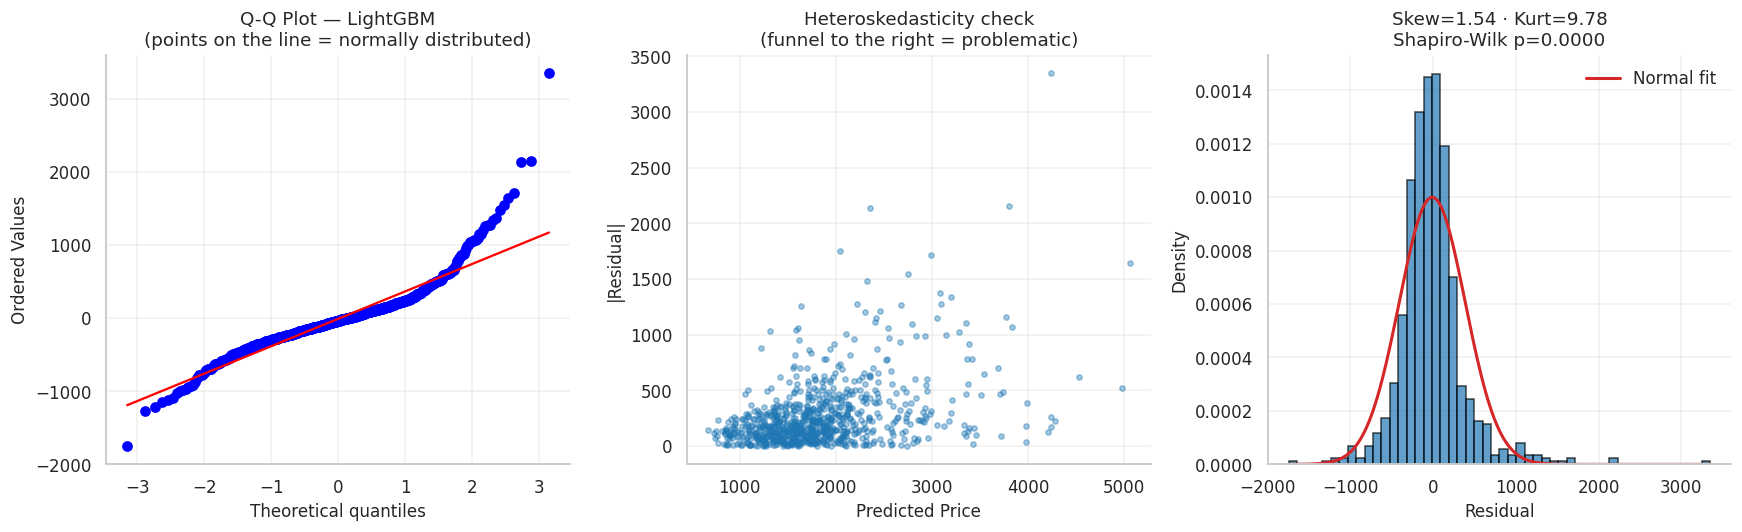

Skewness  : +1.538 (0 = symmetric; |x| > 0.5 clearly skewed)
Kurtosis  : +9.776 (0 = normal; >0 fat tails, <0 thin tails)
Shapiro-Wilk p-value: 0.0000  (p < 0.05 → reject normality assumption)


In [46]:
import scipy.stats as stats

# We use y_pred and residuals from the residual-analysis section
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title(f'Q-Q Plot — {best_name}\n(points on the line = normally distributed)')
axes[0].grid(True, alpha=0.3)

# (b) Heteroskedasticity
axes[1].scatter(y_pred, np.abs(residuals), alpha=0.4, s=12)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('|Residual|')
axes[1].set_title('Heteroskedasticity check\n(funnel to the right = problematic)')
axes[1].grid(True, alpha=0.3)

# (c) Skewness/kurtosis statistics
skew_val = stats.skew(residuals)
kurt_val = stats.kurtosis(residuals)
shapiro_p = stats.shapiro(residuals[:min(5000, len(residuals))]).pvalue
axes[2].hist(residuals, bins=50, edgecolor='black', density=True, alpha=0.7)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             color=NOTEBOOK_COLORS['reference'], linewidth=2, label='Normal fit')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Density')
axes[2].set_title(f'Skew={skew_val:.2f} · Kurt={kurt_val:.2f}\nShapiro-Wilk p={shapiro_p:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Skewness  : {skew_val:+.3f} (0 = symmetric; |x| > 0.5 clearly skewed)')
print(f'Kurtosis  : {kurt_val:+.3f} (0 = normal; >0 fat tails, <0 thin tails)')
print(f'Shapiro-Wilk p-value: {shapiro_p:.4f}  (p < 0.05 → reject normality assumption)')


### 21.6 Partial Dependence Plots for the Top Features

Partial dependence plots show how the model prediction changes when one feature
moves while the other features stay distributed as in the training data. They
help translate the model from a black-box prediction tool into an interpretable
real-estate story.

PDP for top-6 features: ['area', 'east', 'north', 'area_per_room', 'year_built', 'oev']


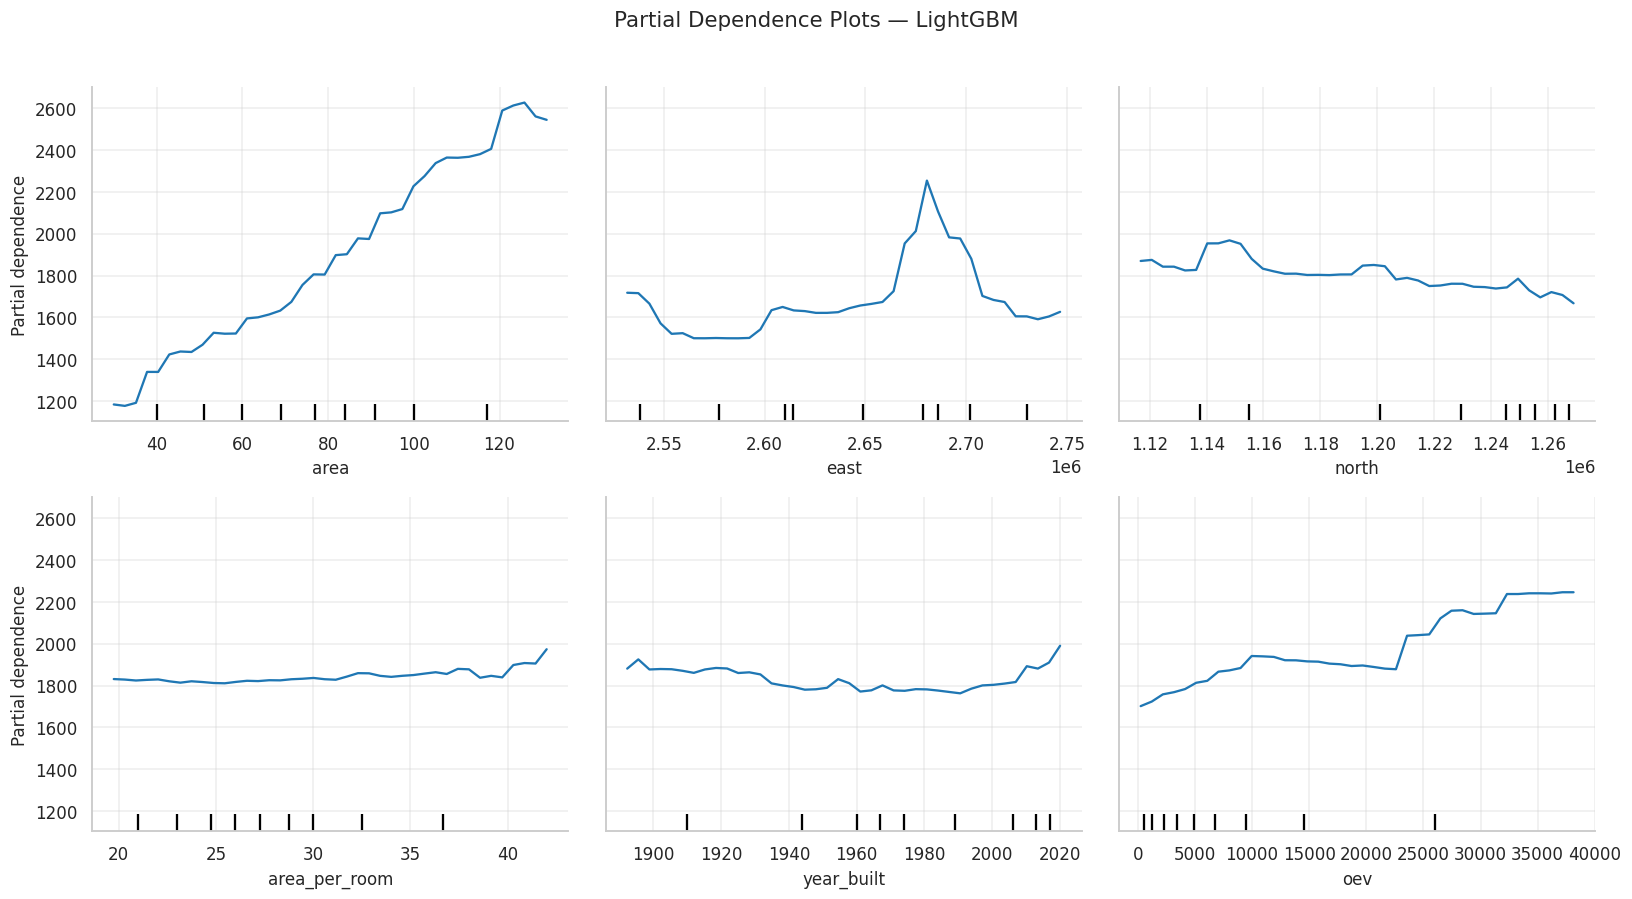

In [47]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.base       import clone

# Top-six features from the feature-importance section
top_features = fi.head(6).index.tolist()
print(f'PDP for top-{len(top_features)} features: {top_features}')

# IMPORTANT: cast integer columns to float64.
# Otherwise pandas >= 2.0 raises a LossySetitemError when PDP
# writes floating grid values, such as year_built=1892.31, into an int64 column.
X_pdp = train_df[main_features].astype('float64')
y_pdp = train_df[TARGET_COL].astype('float64')

# Clone the model and set the inner n_jobs=1 to avoid nested parallelism
_pdp_model = clone(main_fitted[best_name])
try:
    _pdp_model.set_params(n_jobs=1)
except (ValueError, AttributeError):
    pass
_pdp_model.fit(X_pdp, y_pdp)  # refit on the float DataFrame

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(
    _pdp_model,
    X_pdp,
    features=top_features,
    ax=axes,
    n_jobs=-1,
    grid_resolution=40,
)
plt.suptitle(f'Partial Dependence Plots — {best_name}', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 21.7 Bootstrap Confidence Interval for RMSE

A single eval RMSE is only a point estimate. Bootstrapping the eval predictions
adds uncertainty bands around the metric. If two models have strongly overlapping
intervals, their difference is not practically meaningful enough to drive the
final decision alone.

,Model,RMSE_2.5%,RMSE_median,RMSE_97.5%,CI_width
0,LightGBM,356.7,396.7,446.9,90.2
1,XGBoost,369.7,417.5,476.4,106.7
2,GradientBoosting,374.5,420.1,487.7,113.2
3,RandomForest,373.8,420.9,485.2,111.4
4,Ridge (scaled),505.8,557.6,622.3,116.5
5,Dummy (median),713.1,797.0,882.9,169.7


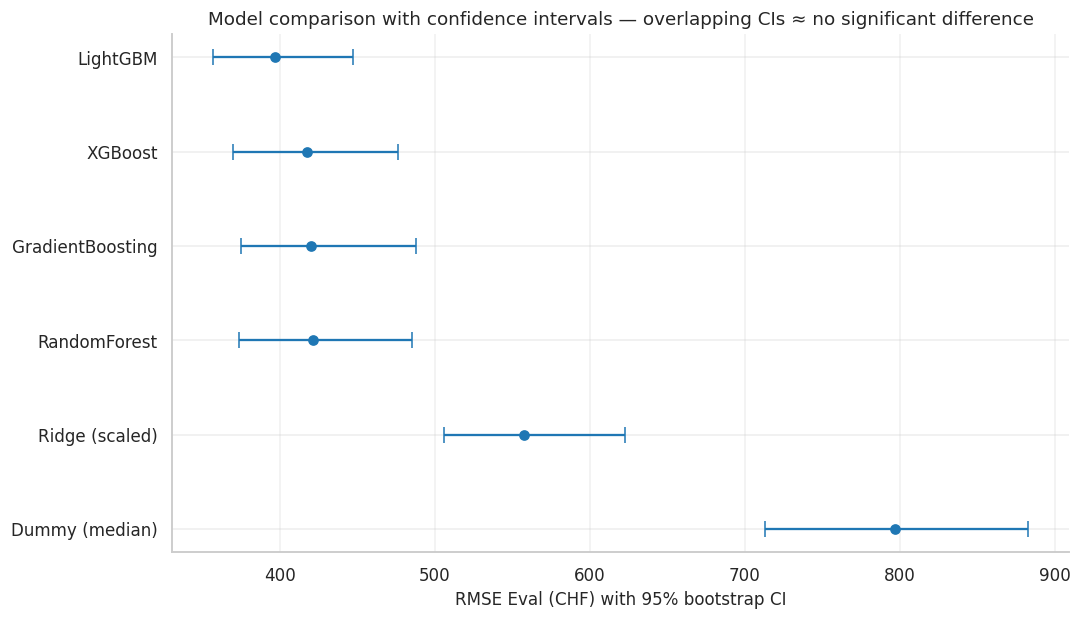

In [48]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_iter=1000, seed=RANDOM_STATE):
    """Bootstrap CI (2.5/50/97.5 quantiles) for a regression metric."""
    rng = np.random.RandomState(seed)
    n   = len(y_true)
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    samples = []
    for _ in range(n_iter):
        idx = rng.randint(0, n, n)
        samples.append(metric_fn(y_true_arr[idx], y_pred_arr[idx]))
    return np.percentile(samples, [2.5, 50, 97.5])


boot_records = []
y_eval_arr   = eval_df[TARGET_COL].values
for name in main_results['Model']:
    y_pred_arr = main_cache[name]['eval']
    lo, med, hi = bootstrap_metric_ci(y_eval_arr, y_pred_arr, rmse, n_iter=1000)
    boot_records.append({
        'Model':       name,
        'RMSE_2.5%':   lo,
        'RMSE_median': med,
        'RMSE_97.5%':  hi,
        'CI_width':    hi - lo,
    })
boot_df = pd.DataFrame(boot_records).sort_values('RMSE_median').reset_index(drop=True)
display(boot_df.round(1))

# Visualization: forest plot of the CIs
fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
y_pos = np.arange(len(boot_df))
ax.errorbar(
    boot_df['RMSE_median'], y_pos,
    xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
          boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
    fmt='o', capsize=5,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(boot_df['Model'])
ax.set_xlabel('RMSE Eval (CHF) with 95% bootstrap CI')
ax.set_title('Model comparison with confidence intervals — overlapping CIs ≈ no significant difference')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 21.8 Actual vs Predicted for All Models

Instead of looking only at the leading model, we compare prediction patterns for
all candidates. This makes systematic weaknesses visible, especially the
underestimation of very expensive apartments.

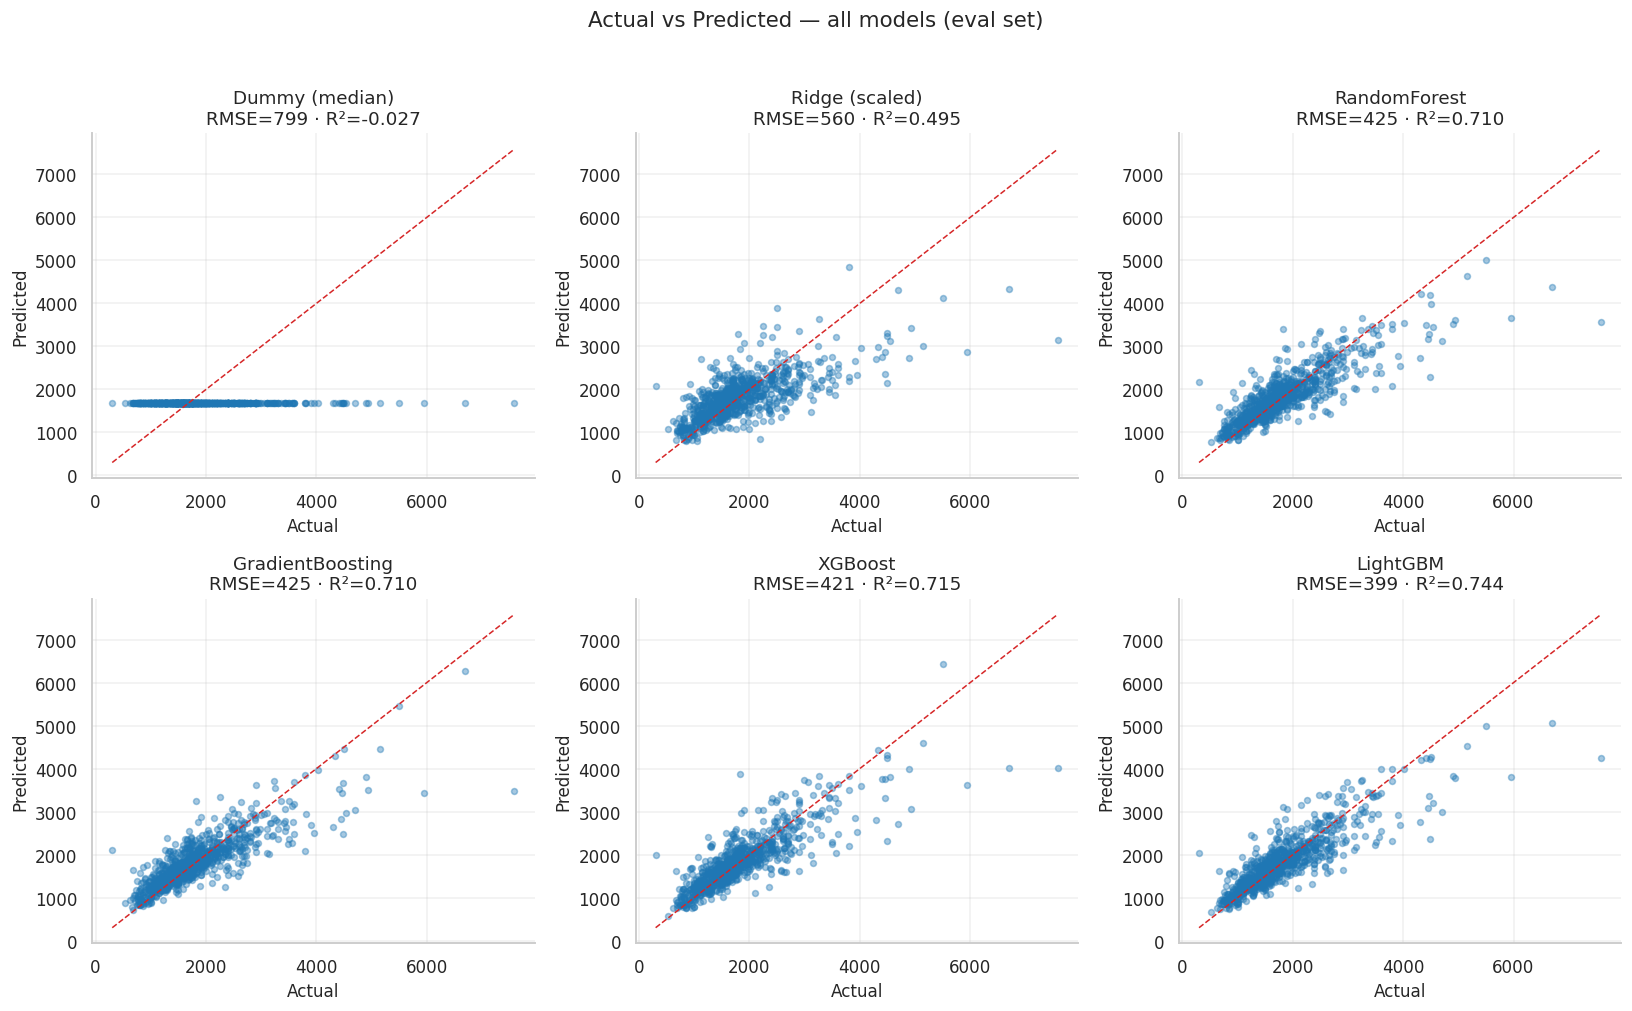

In [49]:
n_models_plot = len(main_cache)
n_cols_plot   = min(3, n_models_plot)
n_rows_plot   = int(np.ceil(n_models_plot / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(5 * n_cols_plot, 4.5 * n_rows_plot),
                          squeeze=False)
axes_flat = axes.flatten()

y_eval_full = eval_df[TARGET_COL]

for ax, (name, preds) in zip(axes_flat, main_cache.items()):
    y_pred_m = preds['eval']
    rmse_m   = rmse(y_eval_full, y_pred_m)
    r2_m     = r2_score(y_eval_full, y_pred_m)

    ax.scatter(y_eval_full, y_pred_m, alpha=0.4, s=15)
    lo = float(min(y_eval_full.min(), y_pred_m.min()))
    hi = float(max(y_eval_full.max(), y_pred_m.max()))
    ax.plot([lo, hi], [lo, hi], color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nRMSE={rmse_m:.0f} · R²={r2_m:.3f}')
    ax.grid(True, alpha=0.3)

for ax in axes_flat[n_models_plot:]:
    ax.axis('off')

plt.suptitle('Actual vs Predicted — all models (eval set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 21.9 Feature Importance Comparison Across Methods

Feature importance can depend on the method used. We therefore compare impurity,
LightGBM split counts, permutation importance, and rank correlation. Features
that remain important across methods are more trustworthy than features that
only appear in one ranking.

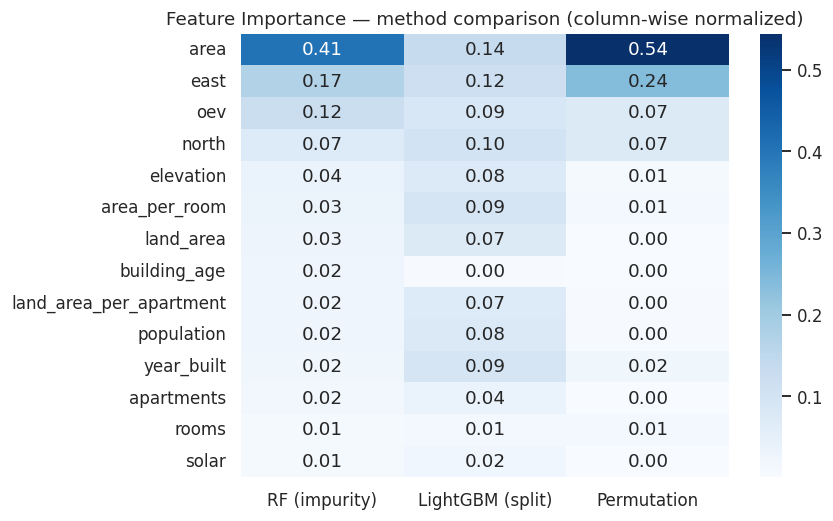

Spearman rank correlation of importance methods (1.0 = identical ranking):


,RF (impurity),LightGBM (split),Permutation
RF (impurity),1.00,0.75,0.67
LightGBM (split),0.75,1.00,0.87
Permutation,0.67,0.87,1.00


In [50]:
from sklearn.inspection import permutation_importance
from scipy.stats         import spearmanr

X_eval_for_imp = eval_df[main_features]
y_eval_for_imp = eval_df[TARGET_COL]

imp_dict = {}

if 'RandomForest' in main_fitted:
    imp_dict['RF (impurity)'] = pd.Series(
        main_fitted['RandomForest'].feature_importances_, index=main_features,
    )
if 'LightGBM' in main_fitted:
    lgbm_imp = main_fitted['LightGBM'].feature_importances_.astype(float)
    imp_dict['LightGBM (split)'] = pd.Series(
        lgbm_imp / lgbm_imp.sum(), index=main_features,
    )

perm = permutation_importance(
    main_fitted[best_name], X_eval_for_imp, y_eval_for_imp,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
imp_dict['Permutation'] = pd.Series(perm.importances_mean, index=main_features)

imp_df = pd.DataFrame(imp_dict).fillna(0)
# Normalize per column (sum = 1) for fair comparability
imp_norm = imp_df.div(imp_df.sum(axis=0).replace(0, 1), axis=1)
imp_norm = imp_norm.sort_values(by=imp_norm.columns[0], ascending=False)

# Heatmap
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax)
ax.set_title('Feature Importance — method comparison (column-wise normalized)')
plt.tight_layout()
plt.show()

# Spearman correlation of rankings
rank_df = imp_df.rank(method='min', ascending=False)
rank_corr = rank_df.corr(method='spearman')
print('Spearman rank correlation of importance methods (1.0 = identical ranking):')
display(rank_corr.round(2))


In [51]:
save_fig("feature_importance_heatmap.png", fig)


Saved figure: ../../docs/final-report/fig/feature_importance_heatmap.png


### 21.10 Robust Selection Score: RMSE plus Stability

This section formalizes the robustness idea by adding a penalty for high CV
standard deviation. A lower score means the model is accurate and stable across
folds. This supports the final selection logic: the model should not only be
strong on one eval split, but also reliable under resampling.

In [52]:
STABILITY_WEIGHT = 1.0  # How strongly CV std is penalized; 0 = only eval RMSE counts

stab = main_results_full[['Model', 'RMSE Eval', 'CV_RMSE_mean', 'CV_RMSE_std']].copy()
stab['Stability_Score'] = stab['RMSE Eval'] + STABILITY_WEIGHT * stab['CV_RMSE_std']
stab = stab.sort_values('Stability_Score').reset_index(drop=True)

print(f'Model selection with stability score (RMSE Eval + {STABILITY_WEIGHT}·CV_RMSE_std):')
display(stab.round(2))

best_stable_model_name = stab.iloc[0]['Model']
print(f'\nBest candidate by stability score: {best_stable_model_name}')
if best_stable_model_name != best_name:
    print(f'⚠️  Difference from the preliminary RMSE winner ({best_name}) — the old model may have been lucky with the split.')
else:
    print('✅ Consistent with the preliminary RMSE winner.')


Model selection with stability score (RMSE Eval + 1.0·CV_RMSE_std):


,Model,RMSE Eval,CV_RMSE_mean,CV_RMSE_std,Stability_Score
0,LightGBM,399.17,413.36,11.77,410.93
1,XGBoost,420.81,418.61,15.39,436.20
2,GradientBoosting,424.71,436.59,11.81,436.52
3,RandomForest,424.91,431.28,17.06,441.97
4,Ridge (scaled),560.07,541.74,13.36,573.43
5,Dummy (median),799.09,737.26,21.96,821.05



Best candidate by stability score: LightGBM
✅ Consistent with the preliminary RMSE winner.


### 21.11 KNN-Based Distance Features

Nearby apartments often share the same local price level. The KNN features ask a
simple question: what do the nearest training listings cost? Because the KNN is
fit only on the train set, eval listings never use their own price as a neighbor,
which avoids leakage.

In [53]:
from sklearn.neighbors import NearestNeighbors

if has_full_geo:
    K_NEIGHBORS = 10

    # KNN on scaled coordinates — otherwise absolute values dominate
    coord_scaler = StandardScaler().fit(train_df[['east', 'north']])
    train_coords = coord_scaler.transform(train_df[['east', 'north']])
    eval_coords  = coord_scaler.transform(eval_df[['east', 'north']])

    nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(train_coords)

    # For train: exclude self-match (index 0), otherwise the listing's own price leaks
    _, idx_train = nbrs.kneighbors(train_coords)
    idx_train = idx_train[:, 1:]  # 1..K

    # For eval: take all K neighbors; no self-match is possible because eval ≠ train index
    _, idx_eval = nbrs.kneighbors(eval_coords)
    idx_eval = idx_eval[:, :K_NEIGHBORS]

    train_prices_arr = train_df[TARGET_COL].values

    train_df_knn = train_df.copy()
    eval_df_knn  = eval_df.copy()
    train_df_knn['knn_price_mean']   = train_prices_arr[idx_train].mean(axis=1)
    train_df_knn['knn_price_median'] = np.median(train_prices_arr[idx_train], axis=1)
    eval_df_knn['knn_price_mean']    = train_prices_arr[idx_eval].mean(axis=1)
    eval_df_knn['knn_price_median']  = np.median(train_prices_arr[idx_eval], axis=1)

    FEATURES_KNN = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']

    res_knn, fitted_knn, _ = evaluate_models(
        train_df_knn, eval_df_knn, FEATURES_KNN, TARGET_COL, make_models(),
    )
    print(f'KNN-Distance-Features (k={K_NEIGHBORS}):')
    display(res_knn)

    print(f'\nComparison:')
    print(f'  Best without KNN feature: RMSE Eval = {main_results.iloc[0]["RMSE Eval"]:.1f}')
    print(f'  Best with    KNN feature: RMSE Eval = {res_knn.iloc[0]["RMSE Eval"]:.1f}')
else:
    print('KNN distance features skipped — east/north are missing.')


KNN-Distance-Features (k=10):


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,98.120199,261.360371,73.357807,181.098701,139.410985,393.349408,0.962952,0.751074,253.938423
1,XGBoost,83.733017,270.249481,60.597839,180.420532,119.355704,408.322119,0.972844,0.731763,288.966415
2,GradientBoosting,242.568057,280.961142,180.128764,201.532338,340.056903,412.113448,0.779567,0.726759,72.056546
3,RandomForest,122.105156,281.321905,82.341891,185.735589,194.552297,422.871561,0.927848,0.712307,228.319264
4,Ridge (scaled),314.314306,319.384992,228.391601,223.787685,452.133723,467.796087,0.610320,0.647933,15.662364
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154



Comparison:
  Best without KNN feature: RMSE Eval = 399.2
  Best with    KNN feature: RMSE Eval = 393.3


## 22. Model Card

The model card turns the technical results into a compact project summary. It
states the final model, intended use, limitations, evaluation method, and
reproducibility information. This is the bridge from exploration to a model that
can be communicated and reviewed.

### 22.1 Final Model Card

**Final model type:** `GradientBoostingRegressor` with the `ALL+geo` feature set
(see Section 20).

**Reason for selection:** The final model is not the most aggressive model by
raw eval RMSE. It is selected because it has the strongest overfitting-gap
profile among the relevant `ALL+geo` candidates. We accept a slightly lower
absolute accuracy because the smaller train/eval gap makes the model more
robust and easier to justify.

**Intended Use:** Prediction of cold rents for Swiss apartments based on
apartment characteristics and location data. Suitable for market analyses and
initial price estimates.

**Out-of-Scope:** Legally binding rent calculation, investment decisions,
estimation outside the Swiss geo domain (LV95 coordinates).

**Training data:**

- Source: `model.csv`
- Preprocessing: duplicate removal and conservative outlier filter (`area >= 10`, `price >= 300`)
- Split logic: fixed `random_state=42`, train/eval split for model development
- Final features: `FEATURES_ALL + ['geo_cluster']`

**Evaluation metrics:** MAE, RMSE, MedAE, R², train/eval overfitting gap, and
cross-validation stability.

**Limitations:**

- The final model is slightly less accurate than the lowest-RMSE alternative.
- Rents are right-skewed, so predictions are less certain for very expensive apartments.
- The data does not contain qualitative variables such as floor, view, renovation state, or interior standard.
- There is no time component; if the market changes, the model must be retrained.

**Fairness / Bias:**

- Geo-cluster analysis is used to check location-dependent error patterns.
- Drift and stability checks are included in the diagnostic sections.

**Reproducibility:**

- `RANDOM_STATE = 42`, `REFERENCE_YEAR = 2026`
- Pipeline artifact: `models/gradient_boosting_all_geo.joblib`
- Notebook version: `model_v3_clean_english_story.ipynb`
- Dependency pins: see `requirements.txt`

### 22.2 Consolidated Model Comparison

This table brings together the main variants tested across the notebook. It is
useful for transparency: the final model choice can be compared against tuned,
stacked, KNN-enhanced, and regularized alternatives instead of being presented
in isolation.

In [54]:
# Build the comparison list directly from the variants that still exist
# in the cleaned notebook so this section stays self-contained.
summary_blocks2 = [
    main_results.assign(Variant='Baseline comparison', FeatureSet='ENGINEERED')
]

if has_full_geo and 'geo_results_df' in globals():
    summary_blocks2.append(geo_results_df.assign(Variant='Geo cluster comparison'))
if HAS_LGBM and 'res_tuned' in globals() and tuned_lgbm is not None:
    summary_blocks2.append(res_tuned.assign(Variant='Tuned LGBM', FeatureSet='ENGINEERED'))
if len(stack_fitted) > 0:
    summary_blocks2.append(stack_results.assign(Variant='Stacking', FeatureSet='ENGINEERED'))
if has_full_geo and 'res_knn' in globals():
    summary_blocks2.append(res_knn.assign(Variant='KNN-Distance', FeatureSet='ENGINEERED+KNN'))
if HAS_LGBM and globals().get('HAS_HALVING', False) and 'res_halving' in globals():
    summary_blocks2.append(res_halving.assign(Variant='LGBM Halving-Tuned', FeatureSet='ENGINEERED'))

summary_v23 = (
    pd.concat(summary_blocks2, ignore_index=True)
    [['Variant', 'FeatureSet', 'Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']]
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)
print('Complete comparison of all evaluated variants:')
display(summary_v23.head(25))

best_overall_accuracy = summary_v23.iloc[0]
print(f'\nBest run by raw eval RMSE: {best_overall_accuracy["Variant"]} → {best_overall_accuracy["Model"]}')
print(f'    RMSE Eval = {best_overall_accuracy["RMSE Eval"]:.1f} CHF, R² = {best_overall_accuracy["R² Eval"]:.3f}')

if 'final_metrics' in globals():
    print('\nFinal model by robustness criterion:')
    print(f'    {FINAL_FEATURE_SET} → {FINAL_MODEL_NAME}')
    print(f'    RMSE Eval = {final_metrics["RMSE Eval"]:.1f} CHF, Gap = {final_metrics["Overfitting Gap"]:.1f} CHF')


Complete comparison of all evaluated variants:


,Variant,FeatureSet,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap
0,KNN-Distance,ENGINEERED+KNN,LightGBM,139.410985,393.349408,0.751074,253.938423
1,Tuned LGBM,ENGINEERED,LightGBM_tuned,161.051558,393.802771,0.750500,232.751214
2,Geo cluster comparison,ENGINEERED+geo,LightGBM,148.632283,395.356652,0.748527,246.724369
3,Geo cluster comparison,ALL+geo,LightGBM,162.831986,397.848403,0.745348,235.016417
4,Stacking,ENGINEERED,Stacking,177.986277,399.105812,0.743735,221.119535
5,Baseline comparison,ENGINEERED,LightGBM,150.286423,399.166141,0.743658,248.879718
6,Geo cluster comparison,ENGINEERED,LightGBM,150.286423,399.166141,0.743658,248.879718
7,Geo cluster comparison,ALL,LightGBM,164.153581,403.349280,0.738257,239.195699
8,Geo cluster comparison,ALL,XGBoost,139.462017,407.013936,0.733479,267.551918
9,KNN-Distance,ENGINEERED+KNN,XGBoost,119.355704,408.322119,0.731763,288.966415



Best run by raw eval RMSE: KNN-Distance → LightGBM
    RMSE Eval = 393.3 CHF, R² = 0.751

Final model by robustness criterion:
    ALL+geo → GradientBoosting
    RMSE Eval = 423.4 CHF, Gap = 56.7 CHF


## 23. Production Wrapper and Hold-Out Test

So far, the notebook has built the pipeline step by step. To make it usable in a
Streamlit demo or another application, the logic is wrapped into a
`RentPredictor` class. The class handles loading, cleaning, feature engineering,
geo clustering, fitting, predicting, saving, and loading.

The hold-out split at the end checks whether the model-selection process has
become too dependent on the eval set. This is the final sanity check before
communicating the result.

### 23.1 End-to-End `RentPredictor` Class

The production-style API turns a raw DataFrame into predictions with one
consistent transformation sequence. All sub-models are fitted on training data
only, and the same preprocessing order is applied during `predict`. This is the
main protection against training/inference mismatch.

In [55]:
from sklearn.cluster   import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.impute    import SimpleImputer

class RentPredictor:
    """End-to-end pipeline for rent prediction.

    Expects a DataFrame with the standard columns after the rename step.
    """

    def __init__(
        self,
        target_col='price',
        feature_cols=None,
        n_geo_clusters=8,
        knn_k=10,
        outlier_min_area=10,
        outlier_min_price=300,
        reference_year=2026,
        random_state=42,
        model=None,
    ):
        self.target_col       = target_col
        self.feature_cols     = feature_cols
        self.n_geo_clusters   = n_geo_clusters
        self.knn_k            = knn_k
        self.outlier_min_area = outlier_min_area
        self.outlier_min_price = outlier_min_price
        self.reference_year   = reference_year
        self.random_state     = random_state
        self.model            = model

    def _clean(self, df, training=True):
        out = df.copy()
        if training:
            mask = (out['area'] >= self.outlier_min_area)
            if self.target_col in out.columns:
                mask &= (out[self.target_col] >= self.outlier_min_price)
            out = out[mask].drop_duplicates().reset_index(drop=True)
        return out

    def _engineer(self, df):
        out = df.copy()
        if 'year_built' in out.columns:
            out['building_age'] = self.reference_year - out['year_built']
        if 'rooms' in out.columns and 'area' in out.columns:
            out['area_per_room'] = np.where(out['rooms'] > 0, out['area'] / out['rooms'], np.nan)
        if 'apartments' in out.columns and 'land_area' in out.columns:
            out['land_area_per_apartment'] = np.where(
                out['apartments'] > 0, out['land_area'] / out['apartments'], np.nan,
            )
        return out

    def _geo_cluster(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._geo_pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('km',     KMeans(n_clusters=self.n_geo_clusters,
                                  random_state=self.random_state, n_init=10)),
            ])
            self._geo_pipe.fit(df[cols])
        out = df.copy()
        out['geo_cluster'] = self._geo_pipe.predict(out[cols])
        return out

    def _knn_features(self, df, fit=False):
        cols = ['east', 'north']
        if not all(c in df.columns for c in cols):
            return df
        if fit:
            self._coord_scaler = StandardScaler().fit(df[cols])
            self._train_coords = self._coord_scaler.transform(df[cols])
            self._train_prices = df[self.target_col].values
            self._nbrs = NearestNeighbors(n_neighbors=self.knn_k + 1).fit(self._train_coords)
            _, idx = self._nbrs.kneighbors(self._train_coords)
            idx = idx[:, 1:]
            out = df.copy()
            out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
            out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
            return out
        coords_q = self._coord_scaler.transform(df[cols])
        _, idx = self._nbrs.kneighbors(coords_q, n_neighbors=self.knn_k)
        out = df.copy()
        out['knn_price_mean']   = self._train_prices[idx].mean(axis=1)
        out['knn_price_median'] = np.median(self._train_prices[idx], axis=1)
        return out

    def fit(self, df):
        df_c = self._clean(df, training=True)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=True)
        df_k = self._knn_features(df_g, fit=True)

        if self.feature_cols is None:
            base = ['east', 'north', 'elevation', 'area', 'rooms', 'year_built',
                    'apartments', 'land_area', 'population', 'oev', 'solar',
                    'building_age', 'area_per_room', 'land_area_per_apartment',
                    'geo_cluster', 'knn_price_mean', 'knn_price_median']
            self.feature_cols = [c for c in base if c in df_k.columns]

        self._imputer = SimpleImputer(strategy='median')
        X = self._imputer.fit_transform(df_k[self.feature_cols])
        y = df_k[self.target_col].values

        if self.model is None:
            self.model = GradientBoostingRegressor(random_state=self.random_state)
        self.model.fit(X, y)
        self._is_fitted = True
        return self

    def predict(self, df):
        if not getattr(self, '_is_fitted', False):
            raise RuntimeError('RentPredictor has not been fitted yet — call fit() first.')
        df_c = self._clean(df, training=False)
        df_e = self._engineer(df_c)
        df_g = self._geo_cluster(df_e, fit=False)
        df_k = self._knn_features(df_g, fit=False)

        for c in self.feature_cols:
            if c not in df_k.columns:
                df_k[c] = np.nan
        X = self._imputer.transform(df_k[self.feature_cols])
        return self.model.predict(X)


_final_feature_cols_for_predictor = globals().get('final_feature_cols', FEATURES_ALL + ['geo_cluster'])
_final_geo_k_for_predictor = globals().get('best_k', 8) or 8

rp = RentPredictor(
    target_col=TARGET_COL,
    feature_cols=_final_feature_cols_for_predictor,
    n_geo_clusters=_final_geo_k_for_predictor,
    knn_k=10,
    random_state=RANDOM_STATE,
    reference_year=REFERENCE_YEAR,
    model=GradientBoostingRegressor(random_state=RANDOM_STATE),
)
rp.fit(df_for_split)
preds_demo = rp.predict(eval_df.drop(columns=[TARGET_COL]))
print(f'RentPredictor: {len(rp.feature_cols)} features, model={type(rp.model).__name__}')
print(f'Demo predictions on eval_df: {len(preds_demo)} values, mean={preds_demo.mean():.0f} CHF')
rmse_demo = rmse(eval_df[TARGET_COL], preds_demo)
print(f'RMSE Eval: {rmse_demo:.1f} CHF')


RentPredictor: 12 features, model=GradientBoostingRegressor
Demo predictions on eval_df: 840 values, mean=1837 CHF
RMSE Eval: 360.4 CHF


### 23.2 Sanity Tests for Predictions

Programmatic sanity tests check whether the final predictions are plausible. If
one of these tests fails, something is wrong with the pipeline, the data, or the
model artifact before any result should be used in a report.

In [56]:
def run_sanity_tests(predictor, eval_df, target_col, verbose=True):
    failures = []
    X_eval = eval_df.drop(columns=[target_col], errors='ignore')
    y_pred = predictor.predict(X_eval)

    n_nan = int(np.isnan(y_pred).sum())
    if n_nan > 0:
        failures.append(f'  FAIL: {n_nan} NaN-Predictions')
    elif verbose:
        print('  OK: No NaN predictions')

    n_neg = int((y_pred <= 0).sum())
    if n_neg > 0:
        failures.append(f'  FAIL: {n_neg} Predictions <= 0')
    elif verbose:
        print('  OK: All predictions > 0')

    too_low  = int((y_pred < 50).sum())
    too_high = int((y_pred > 20000).sum())
    if too_low or too_high:
        failures.append(f'  FAIL: {too_low} < 50 CHF and {too_high} > 20000 CHF')
    elif verbose:
        print(f'  OK: Predictions in [50, 20000] CHF (min={y_pred.min():.0f}, max={y_pred.max():.0f})')

    std_pred = float(y_pred.std())
    if std_pred < 50:
        failures.append(f'  FAIL: prediction std too small: {std_pred:.1f}')
    elif verbose:
        print(f'  OK: prediction std = {std_pred:.0f} CHF')

    base = eval_df.iloc[[0]].drop(columns=[target_col], errors='ignore').copy()
    if 'area' in base.columns and base['area'].iloc[0] > 0:
        base_double = base.copy()
        base_double['area'] = base['area'].iloc[0] * 2
        try:
            p1 = predictor.predict(base)[0]
            p2 = predictor.predict(base_double)[0]
            if p2 <= p1:
                failures.append(f'  FAIL: Monotonicity - area*2 -> no higher price ({p1:.0f} -> {p2:.0f})')
            elif verbose:
                print(f'  OK: Monotonicity - area*2 -> price {p1:.0f} -> {p2:.0f}')
        except Exception as e:
            failures.append(f'  FAIL: Monotonicity test crashed: {type(e).__name__}: {e}')

    if failures:
        print('\nFailures:')
        for f in failures: print(f)
        return False
    print('\nAll sanity tests passed.')
    return True


run_sanity_tests(rp, eval_df, TARGET_COL)


  OK: No NaN predictions
  OK: All predictions > 0
  OK: Predictions in [50, 20000] CHF (min=666, max=6050)
  OK: prediction std = 631 CHF
  OK: Monotonicity - area*2 -> price 2409 -> 3042

All sanity tests passed.


True

### 23.3 Hold-Out Test Split

The eval set has been used repeatedly for comparisons and tuning decisions. For
an honest final check, we create a separate train/validation/test setup. The test
set is held back until the end so that it can act as a final, less biased
estimate of model performance.

In [57]:
df_holdout = df_for_split.copy()
trainval_df, test_df = train_test_split(
    df_holdout, test_size=0.20, random_state=RANDOM_STATE,
)
train_h_df, val_h_df = train_test_split(
    trainval_df, test_size=0.25, random_state=RANDOM_STATE,
)
print(f'Train  : {len(train_h_df)} ({len(train_h_df)/len(df_holdout):.1%})')
print(f'Val    : {len(val_h_df)}  ({len(val_h_df)/len(df_holdout):.1%})')
print(f'Test   : {len(test_df)}  ({len(test_df)/len(df_holdout):.1%})')

final_predictor = RentPredictor(
    target_col=TARGET_COL,
    feature_cols=globals().get('final_feature_cols', FEATURES_ALL + ['geo_cluster']),
    n_geo_clusters=globals().get('best_k', 8) or 8,
    knn_k=10,
    random_state=RANDOM_STATE,
    reference_year=REFERENCE_YEAR,
    model=GradientBoostingRegressor(random_state=RANDOM_STATE),
)
final_predictor.fit(trainval_df)

y_test_true = test_df[TARGET_COL].values
y_test_pred = final_predictor.predict(test_df.drop(columns=[TARGET_COL]))

test_metrics = {
    'MAE Test':   mean_absolute_error(y_test_true, y_test_pred),
    'RMSE Test':  rmse(y_test_true, y_test_pred),
    'MedAE Test': median_absolute_error(y_test_true, y_test_pred),
    'R^2 Test':   r2_score(y_test_true, y_test_pred),
}
print('\n=== HOLD-OUT TEST METRICS (one-time evaluation!) ===')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:8.2f}')

y_val_pred = final_predictor.predict(val_h_df.drop(columns=[TARGET_COL]))
rmse_val   = rmse(val_h_df[TARGET_COL], y_val_pred)
print(f'\nRMSE on val:  {rmse_val:.2f}')
print(f'RMSE on test: {test_metrics["RMSE Test"]:.2f}')
print(f'Delta: {test_metrics["RMSE Test"] - rmse_val:+.2f}  (large positive delta = val overfitting)')


Train  : 2518 (60.0%)
Val    : 840  (20.0%)
Test   : 840  (20.0%)

=== HOLD-OUT TEST METRICS (one-time evaluation!) ===
  MAE Test    :   281.25
  RMSE Test   :   423.40
  MedAE Test  :   190.58
  R^2 Test    :     0.71

RMSE on val:  350.17
RMSE on test: 423.40
Delta: +73.23  (large positive delta = val overfitting)


## 24. Error Deep Dive and Action Items

After the main model is selected, we inspect the worst predictions. The goal is
not only to report an error metric, but to understand what kinds of apartments
cause the largest mistakes and what data would be needed to improve them.

### 24.1 Top-10 Worst Predictions

The expensive segment is the hardest part of the problem, so we inspect the ten
largest errors directly. They usually fall into one of three categories:

1. **True outliers:** unrealistic prices or data-entry problems.
2. **Special cases:** penthouses, furnished apartments, lofts, or unusually high standard.
3. **Structural model limits:** normal-looking apartments whose price cannot be explained by the available features.

This section converts diagnostics into concrete next steps for data collection
and feature engineering.

=== TOP 10 absolute errors ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
238,7590,4241.2,3348.8,3348.8,0.4,176,3,1976,1,182.0
523,5950,3799.2,2150.8,2150.8,0.4,135,3,1992,2,803.0
549,4490,2355.9,2134.1,2134.1,0.5,108,4,2001,6,271.0
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
373,4700,2988.5,1711.5,1711.5,0.4,260,6,1994,1,129.0
250,6700,5057.1,1642.9,1642.9,0.2,228,8,1983,5,872.0
190,4300,2755.2,1544.8,1544.8,0.4,146,4,1914,1,68.0
2,3800,2321.0,1479.0,1479.0,0.4,102,4,1974,5,163.0
228,4450,3079.9,1370.1,1370.1,0.3,115,4,1996,7,205.0
393,4540,3202.1,1337.9,1337.9,0.3,160,6,1962,30,570.0



=== TOP 10 relative errors (% of actual price) ===


,price,predicted,error,abs_error,rel_error,area,rooms,year_built,apartments,land_area
73,300,2047.4,-1747.4,1747.4,5.8,100,4,1926,5,280.0
542,670,1618.2,-948.2,948.2,1.4,48,2,1959,7,182.0
155,1250,2463.3,-1213.3,1213.3,1.0,51,2,1922,1,119.0
454,1293,2407.8,-1114.8,1114.8,0.9,123,4,1921,7,366.0
308,850,1565.1,-715.1,715.1,0.8,82,3,1967,3,117.0
426,850,1552.7,-702.7,702.7,0.8,25,1,1896,3,122.0
387,1070,1942.2,-872.2,872.2,0.8,65,2,1970,9,435.0
455,800,1419.9,-619.9,619.9,0.8,87,3,1982,12,320.0
558,922,1622.0,-700.0,700.0,0.8,100,4,1952,7,313.0
666,1820,3096.0,-1276.0,1276.0,0.7,160,1,2013,100,3149.0



=== Bias analysis for the most expensive 25% of apartments (>= 2132 CHF) ===
Count                    : 210
Mean Error (Actual-Pred) : +278.6 CHF (underestimated)
Median Error             : +213.5 CHF
Mean Abs Error           : 445.3 CHF
Mean Relative Error      : 14.7%


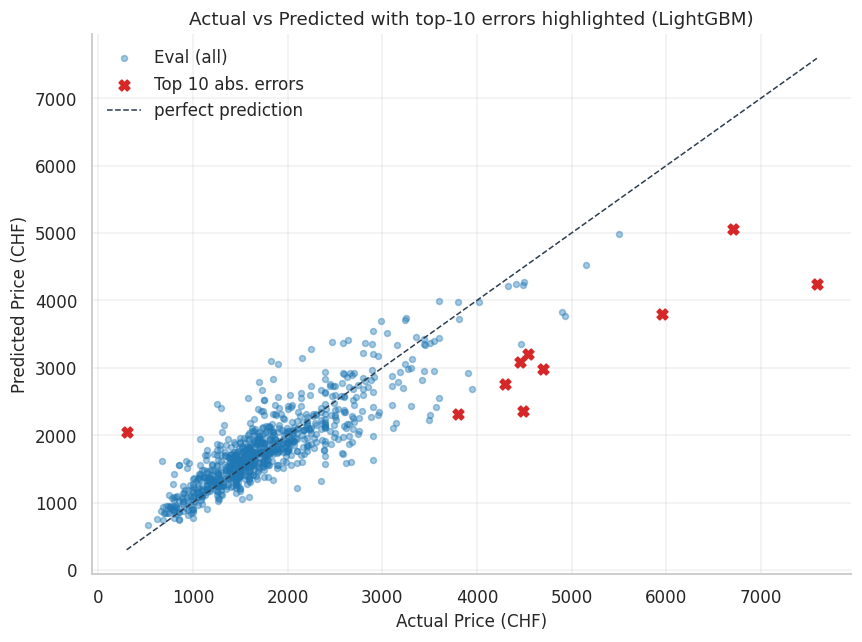

In [58]:
# We use the eval_results DataFrame from the price-segment analysis, supplemented with the
# actual feature values for each row so that we can inspect the profile.

y_pred_eval_full = main_cache[best_name]['eval']
diagnostic_df = eval_df.copy().reset_index(drop=True)
diagnostic_df['predicted']  = y_pred_eval_full
diagnostic_df['error']      = diagnostic_df[TARGET_COL] - diagnostic_df['predicted']
diagnostic_df['abs_error']  = diagnostic_df['error'].abs()
diagnostic_df['rel_error']  = diagnostic_df['abs_error'] / diagnostic_df[TARGET_COL]

# Top 10 absolute errors
print('=== TOP 10 absolute errors ===')
top_abs = diagnostic_df.nlargest(10, 'abs_error')
show_cols_abs = [TARGET_COL, 'predicted', 'error', 'abs_error', 'rel_error',
                 'area', 'rooms', 'year_built', 'apartments', 'land_area']
show_cols_abs = [c for c in show_cols_abs if c in top_abs.columns]
display(top_abs[show_cols_abs].round(1))

# Top 10 relative errors (in percent)
print('\n=== TOP 10 relative errors (% of actual price) ===')
top_rel = diagnostic_df.nlargest(10, 'rel_error')
display(top_rel[show_cols_abs].round(1))

# Statistics by sign — does the model under- or overestimate expensive apartments?
expensive_threshold = diagnostic_df[TARGET_COL].quantile(0.75)
expensive = diagnostic_df[diagnostic_df[TARGET_COL] >= expensive_threshold]
print(f'\n=== Bias analysis for the most expensive 25% of apartments (>= {expensive_threshold:.0f} CHF) ===')
print(f'Count                    : {len(expensive)}')
print(f'Mean Error (Actual-Pred) : {expensive["error"].mean():+.1f} CHF '
      f'({"underestimated" if expensive["error"].mean() > 0 else "overestimated"})')
print(f'Median Error             : {expensive["error"].median():+.1f} CHF')
print(f'Mean Abs Error           : {expensive["abs_error"].mean():.1f} CHF')
print(f'Mean Relative Error      : {expensive["rel_error"].mean()*100:.1f}%')

# Plot: actual vs predicted, with expensive apartments highlighted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(diagnostic_df[TARGET_COL], diagnostic_df['predicted'],
           alpha=0.4, s=15, label='Eval (all)')
ax.scatter(top_abs[TARGET_COL], top_abs['predicted'],
           color=NOTEBOOK_COLORS['reference'], s=50, marker='X', label='Top 10 abs. errors', zorder=5)
lo = float(min(diagnostic_df[TARGET_COL].min(), diagnostic_df['predicted'].min()))
hi = float(max(diagnostic_df[TARGET_COL].max(), diagnostic_df['predicted'].max()))
ax.plot([lo, hi], [lo, hi], color=NOTEBOOK_COLORS['neutral'], linestyle='--', linewidth=1, label='perfect prediction')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted with top-10 errors highlighted ({best_name})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 25. Regularization Experiment: Can We Reduce Overfitting Further?

Before closing the notebook, we test a more conservative LightGBM setup. The
question is whether stronger regularization and fewer features can reduce the
generalization gap without losing too much accuracy. This is an important
counterfactual to the final GradientBoosting decision.

### 25.1 Regularized LightGBM on Reduced Feature Sets

We train the same regularized LightGBM configuration on several feature sets.
The expectation is that fewer features plus stronger regularization should shrink
the train/eval gap, even if the raw eval RMSE does not improve dramatically.

In [59]:
# === Regularized LightGBM on MINIMAL, TOP6, FULL+KNN ===
# Define the reduced feature sets here so this experiment remains self-contained.
FEATURES_MINIMAL = ['area', 'knn_price_median', 'east', 'north']
FEATURES_TOP6    = ['area', 'knn_price_median', 'knn_price_mean',
                     'east', 'north', 'area_per_room']
FEATURES_FULL_KNN = FEATURES_ENGINEERED + ['knn_price_mean', 'knn_price_median']

# Data basis: train_df_knn / eval_df_knn contain the KNN features from the KNN experiment.
# If the KNN extension was skipped, we fall back to train_df / eval_df;
# the knn_price_* columns will then be missing and corresponding sets will be
# skipped in the loop below via 'missing columns'.
_train_df_knn = train_df_knn if 'train_df_knn' in dir() else train_df
_eval_df_knn  = eval_df_knn  if 'eval_df_knn'  in dir() else eval_df

def _build_regularized_lgbm():
    if not HAS_LGBM:
        return None
    return LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )

overfit_results = []

for set_name, feats in [('MINIMAL (4)',    FEATURES_MINIMAL),
                          ('TOP6 (6)',       FEATURES_TOP6),
                          ('FULL+KNN (17)',  FEATURES_FULL_KNN)]:
    if any(c not in _train_df_knn.columns for c in feats):
        print(f'{set_name}: skipped (missing columns)')
        continue
    lgbm = _build_regularized_lgbm()
    if lgbm is None:
        print('LightGBM not available, skipping')
        break
    res, _, _ = evaluate_models(
        _train_df_knn, _eval_df_knn, feats, TARGET_COL,
        {f'LGBM_reg ({set_name})': lgbm},
    )
    res = res.assign(FeatureSet=set_name, n_features=len(feats))
    overfit_results.append(res)

overfit_df = (
    pd.concat(overfit_results, ignore_index=True)
    [['FeatureSet', 'n_features', 'RMSE Train', 'RMSE Eval',
      'R² Eval', 'Overfitting Gap']]
    .round(2)
)
overfit_df['Gap_ratio'] = (overfit_df['RMSE Eval'] / overfit_df['RMSE Train']).round(2)
print('Regularized LightGBM on three feature sets:')
display(overfit_df)


Regularized LightGBM on three feature sets:


,FeatureSet,n_features,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Gap_ratio
0,MINIMAL (4),4,353.62,429.17,0.70,75.55,1.21
1,TOP6 (6),6,337.39,433.18,0.70,95.79,1.28
2,FULL+KNN (17),16,298.68,418.26,0.72,119.58,1.40


### 25.2 Compare LightGBM Variants with the Final GradientBoosting Model

The regularized LightGBM runs are not evaluated in isolation. We compare them
with two reference points: the original unregularized LightGBM baseline on the
standard engineered dataset and the selected GradientBoosting model on
`ALL+geo`.

This makes the section a broader dataset/model-strategy comparison. The default
LightGBM row shows the strongest raw-RMSE benchmark, the regularized LightGBM
rows show how fewer features and stronger regularization reduce memorization,
and the GradientBoosting `ALL+geo` row shows why the final model is more
robust, even if it is not the lowest-RMSE alternative.

The goal is to separate three effects: algorithm choice, feature-set richness,
and dataset/feature coverage.


Dataset/model comparison: LightGBM variants vs final GradientBoosting


,Model,FeatureSet,n_features,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Gap_ratio,Role
0,LightGBM default,ENGINEERED baseline,14,150.29,399.17,0.74,248.88,2.66,"Lowest-RMSE benchmark, but more overfitted"
1,Regularized LightGBM,MINIMAL (4),4,353.62,429.17,0.70,75.55,1.21,Reduced-complexity stress test
2,Regularized LightGBM,TOP6 (6),6,337.39,433.18,0.70,95.79,1.28,Reduced-complexity stress test
3,Regularized LightGBM,FULL+KNN (17),16,298.68,418.26,0.72,119.58,1.40,Reduced-complexity stress test
4,GradientBoosting,ALL+geo,12,366.74,423.40,0.71,56.66,1.15,Final model: best robustness story


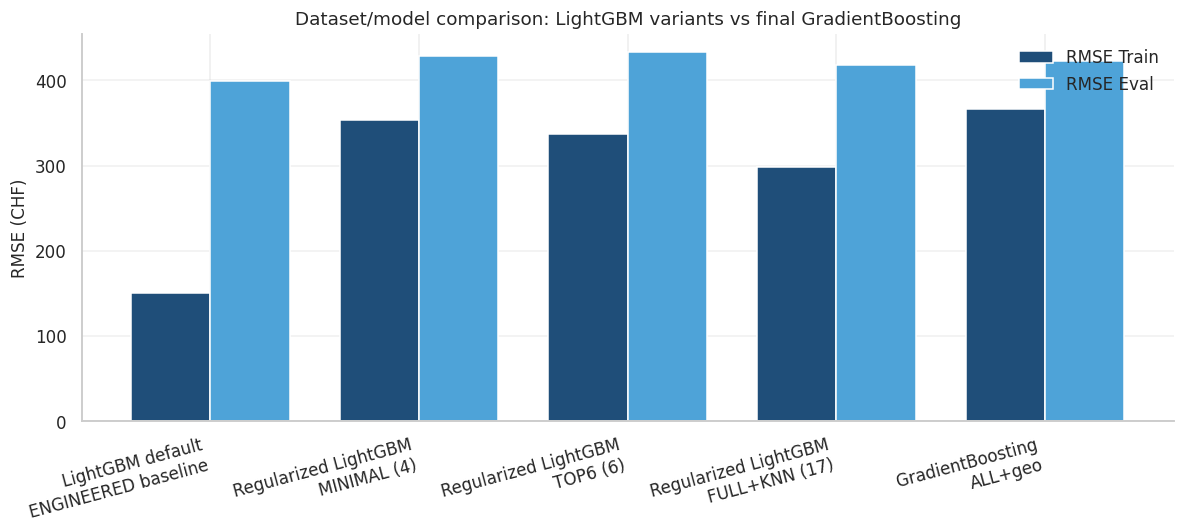

In [60]:
# === Compare LightGBM variants with the final GradientBoosting choice ===
# This table is deliberately broader than a pure LightGBM hyperparameter comparison:
# it puts the final GradientBoosting + ALL+geo choice next to the LightGBM variants.

baseline_row = main_results[main_results['Model'] == 'LightGBM'].iloc[0].to_dict()
baseline = pd.DataFrame([{
    'Model':            'LightGBM default',
    'FeatureSet':       'ENGINEERED baseline',
    'n_features':       len(FEATURES_ENGINEERED),
    'RMSE Train':       baseline_row['RMSE Train'],
    'RMSE Eval':        baseline_row['RMSE Eval'],
    'R² Eval':          baseline_row['R² Eval'],
    'Overfitting Gap':  baseline_row['Overfitting Gap'],
    'Gap_ratio':        round(baseline_row['RMSE Eval'] / baseline_row['RMSE Train'], 2),
    'Role':             'Lowest-RMSE benchmark, but more overfitted',
}])

regularized = overfit_df.copy()
regularized.insert(0, 'Model', 'Regularized LightGBM')
regularized['Role'] = 'Reduced-complexity stress test'

final_reference_rows = []
if 'final_metrics' in globals():
    final_reference_rows.append({
        'Model':            FINAL_MODEL_NAME,
        'FeatureSet':       FINAL_FEATURE_SET,
        'n_features':       len(final_feature_cols),
        'RMSE Train':       final_metrics['RMSE Train'],
        'RMSE Eval':        final_metrics['RMSE Eval'],
        'R² Eval':          final_metrics['R² Eval'],
        'Overfitting Gap':  final_metrics['Overfitting Gap'],
        'Gap_ratio':        round(final_metrics['RMSE Eval'] / final_metrics['RMSE Train'], 2),
        'Role':             'Final model: best robustness story',
    })
elif 'geo_results_df' in globals():
    _final_ref = geo_results_df[
        (geo_results_df['FeatureSet'] == 'ALL+geo') &
        (geo_results_df['Model'] == 'GradientBoosting')
    ]
    if not _final_ref.empty:
        _row = _final_ref.iloc[0]
        final_reference_rows.append({
            'Model':            'GradientBoosting',
            'FeatureSet':       'ALL+geo',
            'n_features':       len(FEATURES_ALL) + 1,
            'RMSE Train':       _row['RMSE Train'],
            'RMSE Eval':        _row['RMSE Eval'],
            'R² Eval':          _row['R² Eval'],
            'Overfitting Gap':  _row['Overfitting Gap'],
            'Gap_ratio':        round(_row['RMSE Eval'] / _row['RMSE Train'], 2),
            'Role':             'Final model: best robustness story',
        })

final_reference = pd.DataFrame(final_reference_rows)

compare_all = pd.concat([baseline, regularized, final_reference], ignore_index=True)
compare_all = compare_all[[
    'Model', 'FeatureSet', 'n_features', 'RMSE Train', 'RMSE Eval',
    'R² Eval', 'Overfitting Gap', 'Gap_ratio', 'Role'
]].round(2)

print('Dataset/model comparison: LightGBM variants vs final GradientBoosting')
display(compare_all)

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
_x = np.arange(len(compare_all))
_w = 0.38
labels = compare_all['Model'] + '\n' + compare_all['FeatureSet']
ax.bar(_x - _w/2, compare_all['RMSE Train'], _w,
       label='RMSE Train', color=NOTEBOOK_COLORS['dark'])
ax.bar(_x + _w/2, compare_all['RMSE Eval'],  _w,
       label='RMSE Eval',  color=NOTEBOOK_COLORS['secondary'])
ax.set_xticks(_x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('RMSE (CHF)')
ax.set_title('Dataset/model comparison: LightGBM variants vs final GradientBoosting')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 26. Wide-Data Experiment: More Rows, Fewer Features

The final experiment changes the data strategy. Instead of using the enriched
standard dataset with fewer rows, we test a wider dataset with many more listings
but fewer features. This answers a practical modeling question: is it better to
have richer features or more observations?

### 26.1 Fetch the Wide Dataset

We query a reduced set of fields: area, rooms, cold rent, coordinates, and basic
population information. If the database is not available, the code falls back to
`model.csv`, so the notebook still remains executable in a local environment.

In [61]:
import sys
!{sys.executable} -m pip install -U psycopg2-binary SQLAlchemy



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [62]:
# === Fetch wide dataset ===
import os
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine

WIDE_QUERY = '''
SELECT DISTINCT
    l.id          AS listing_id,
    ld.area_sqm,
    ld.rooms,
    ld.price_cold,
    sd.lv95_east,
    sd.lv95_north,
    sd.population
FROM listings l
JOIN listing_details ld   ON ld.listing_id = l.id
JOIN swisstopo_details sd ON sd.listing_id = l.id
WHERE ld.area_sqm     IS NOT NULL
  AND ld.price_cold   IS NOT NULL
  AND sd.lv95_east    IS NOT NULL
  AND sd.lv95_north   IS NOT NULL
  AND ld.area_sqm    >= 10
  AND ld.price_cold  >= 300
ORDER BY listing_id
'''

WIDE_CSV = Path('../external-sources/output_csv/model_wide.csv')
DB_URL = os.environ.get(
    "DATABASE_URL",
    "postgresql://neondb_owner:npg_X71kIZjKPMcL"
    "@ep-twilight-cloud-agxexq52.c-2.eu-central-1.aws.neon.tech/DSPRO?sslmode=require"
)

df_wide = None
try:
    from sqlalchemy import create_engine
    engine = create_engine(DB_URL)
    with engine.connect() as conn:
        df_wide = pd.read_sql_query(WIDE_QUERY, conn)
    engine.dispose()
    WIDE_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_wide.to_csv(WIDE_CSV, index=False)
    print(f'Wide dataset loaded from DB: {len(df_wide)} rows')
    print(f'Saved: {WIDE_CSV.resolve()}')
except Exception as exc:
    print(f'DB not reachable ({type(exc).__name__}: {exc}).')
    if WIDE_CSV.exists():
        df_wide = pd.read_csv(WIDE_CSV)
        print(f'Fallback from {WIDE_CSV}: {len(df_wide)} rows')
    else:
        print('No wide CSV available; falling back to model.csv.')
        df_wide = pd.read_csv(DATA_PATH).rename(columns=COLUMN_RENAMES)
        df_wide = df_wide.rename(columns={
            'area': 'area_sqm', 'east': 'lv95_east', 'north': 'lv95_north',
            'price': 'price_cold',
        })
        df_wide = df_wide[['area_sqm', 'rooms', 'price_cold', 'lv95_east',
                            'lv95_north', 'population']].copy()
        print(f'Fallback from model.csv: {len(df_wide)} rows')

# Rename to consistent training columns, as in the main pipeline
df_wide = df_wide.rename(columns={
    'area_sqm':   'area',
    'lv95_east':  'east',
    'lv95_north': 'north',
    'price_cold': 'price',
})
print(f'\nFinal df_wide.shape: {df_wide.shape}')
print(f'Comparison with the standard set:')
print(f'  Standard dataset: {len(train_df) + len(eval_df)} rows ({len(FEATURES_ENGINEERED)+2} features)')
print(f'  Wide dataset    : {len(df_wide)} rows (4 features + target)')


Wide dataset loaded from DB: 9405 rows
Saved: /home/sa_linux/code/Elias-Martinelli/dspro1/src/external-sources/output_csv/model_wide.csv

Final df_wide.shape: (9405, 7)
Comparison with the standard set:
  Standard dataset: 4198 rows (16 features)
  Wide dataset    : 9405 rows (4 features + target)


### 26.2 Split the Wide Data and Build KNN Features

The wide experiment uses the same anti-leakage logic as the main pipeline:
stratified train/eval split, KNN fit on train only, and KNN-based price features
applied to eval through nearest neighbors from the training set.

In [63]:
# === Split + KNN features for the wide dataset ===
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

_df_w = df_wide.dropna(subset=['area', 'price', 'east', 'north']).copy()

# Stratified split by price quartiles
_df_w['_price_band'] = pd.qcut(_df_w['price'], q=10,
                                  labels=False, duplicates='drop')
train_wide, eval_wide = train_test_split(
    _df_w, test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=_df_w['_price_band'],
)
train_wide = train_wide.drop(columns=['_price_band'])
eval_wide  = eval_wide.drop(columns=['_price_band'])
print(f'Train: {len(train_wide)}  |  Eval: {len(eval_wide)}')

# KNN features: 10 nearest neighbors, fit ONLY on train_wide (no leakage)
_coord_cols = ['east', 'north']
_scaler_w = StandardScaler().fit(train_wide[_coord_cols])
_train_coords_w = _scaler_w.transform(train_wide[_coord_cols])
_train_prices_w = train_wide['price'].values
_nbrs_w = NearestNeighbors(n_neighbors=11).fit(_train_coords_w)

# For train: exclude self-match (index 0)
_, _idx_t = _nbrs_w.kneighbors(_train_coords_w)
_idx_t = _idx_t[:, 1:]
train_wide['knn_price_mean']   = _train_prices_w[_idx_t].mean(axis=1)
train_wide['knn_price_median'] = np.median(_train_prices_w[_idx_t], axis=1)

# For eval: neighbors from train
_eval_coords_w = _scaler_w.transform(eval_wide[_coord_cols])
_, _idx_e = _nbrs_w.kneighbors(_eval_coords_w, n_neighbors=10)
eval_wide['knn_price_mean']   = _train_prices_w[_idx_e].mean(axis=1)
eval_wide['knn_price_median'] = np.median(_train_prices_w[_idx_e], axis=1)

FEATURES_WIDE_MINIMAL = ['area', 'knn_price_median', 'east', 'north']
print(f'\nFeatures: {FEATURES_WIDE_MINIMAL}')
print(f'Train shape: {train_wide[FEATURES_WIDE_MINIMAL].shape}')
print(f'Eval shape : {eval_wide[FEATURES_WIDE_MINIMAL].shape}')


Train: 7524  |  Eval: 1881

Features: ['area', 'knn_price_median', 'east', 'north']
Train shape: (7524, 4)
Eval shape : (1881, 4)


### 26.3 Train Regularized LightGBM on the Wide Set

The wide model uses only a small number of features, so the model is kept
regularized. The purpose is to test whether more rows can compensate for less
feature depth.

In [64]:
# === Regularized LightGBM on wide data ===
if HAS_LGBM:
    lgbm_wide = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=15,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=0.5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )
    lgbm_wide.fit(train_wide[FEATURES_WIDE_MINIMAL], train_wide['price'])

    y_pred_train_w = lgbm_wide.predict(train_wide[FEATURES_WIDE_MINIMAL])
    y_pred_eval_w  = lgbm_wide.predict(eval_wide[FEATURES_WIDE_MINIMAL])

    rmse_train_w = rmse(train_wide['price'], y_pred_train_w)
    rmse_eval_w  = rmse(eval_wide['price'],  y_pred_eval_w)
    mae_eval_w   = mean_absolute_error(eval_wide['price'], y_pred_eval_w)
    r2_eval_w    = r2_score(eval_wide['price'], y_pred_eval_w)
    gap_w        = rmse_eval_w - rmse_train_w

    print('LightGBM (regularized) on wide set (4 features, ~9.5k rows)')
    print(f'  RMSE Train  : {rmse_train_w:7.2f}')
    print(f'  RMSE Eval   : {rmse_eval_w:7.2f}')
    print(f'  MAE Eval    : {mae_eval_w:7.2f}')
    print(f'  R^2 Eval    : {r2_eval_w:7.3f}')
    print(f'  Overfit Gap : {gap_w:7.2f}')
    print(f'  Gap Ratio   : {rmse_eval_w / rmse_train_w:.2f}')
else:
    lgbm_wide = None
    print('LightGBM not available')


LightGBM (regularized) on wide set (4 features, ~9.5k rows)
  RMSE Train  :  474.72
  RMSE Eval   :  585.38
  MAE Eval    :  315.16
  R^2 Eval    :   0.619
  Overfit Gap :  110.66
  Gap Ratio   : 1.23


### 26.4 Compare Standard and Wide Pipelines

Here we place the standard enriched dataset next to the wide reduced dataset.
This comparison is not the final model decision, but it helps explain the trade-
off between feature richness and sample size.

Setup A vs Setup B:


,Setup,n_features,n_rows,RMSE Train,RMSE Eval,R2 Eval,Overfit Gap
0,"A: Standard (12 features, ~4.5k rows)",12,4198,150.3,399.2,0.744,248.9
1,"B: Wide (4 features, ~9.5k rows)",4,9405,474.7,585.4,0.619,110.7


Figure saved: /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig/wide_vs_standard.png


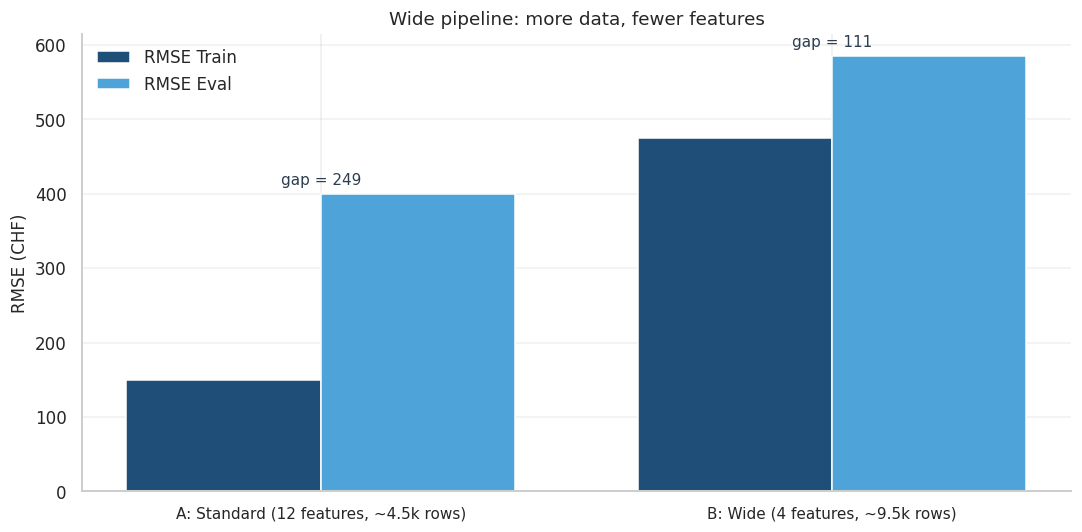

In [65]:
# === Standard-vs-wide comparison ===
_base = main_results[main_results['Model'] == 'LightGBM'].iloc[0]
comparison = pd.DataFrame([
    {
        'Setup':        'A: Standard (12 features, ~4.5k rows)',
        'n_features':   12,
        'n_rows':       len(train_df) + len(eval_df),
        'RMSE Train':   round(_base['RMSE Train'], 1),
        'RMSE Eval':    round(_base['RMSE Eval'], 1),
        'R2 Eval':      round(_base['R\u00b2 Eval'], 3),
        'Overfit Gap':  round(_base['Overfitting Gap'], 1),
    },
    {
        'Setup':        'B: Wide (4 features, ~9.5k rows)',
        'n_features':   len(FEATURES_WIDE_MINIMAL),
        'n_rows':       len(train_wide) + len(eval_wide),
        'RMSE Train':   round(rmse_train_w, 1) if HAS_LGBM else None,
        'RMSE Eval':    round(rmse_eval_w, 1) if HAS_LGBM else None,
        'R2 Eval':      round(r2_eval_w, 3) if HAS_LGBM else None,
        'Overfit Gap':  round(gap_w, 1) if HAS_LGBM else None,
    },
])
print('Setup A vs Setup B:')
display(comparison)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
_x = np.arange(len(comparison))
_w = 0.38
ax.bar(_x - _w/2, comparison['RMSE Train'], _w,
       label='RMSE Train', color=NOTEBOOK_COLORS['dark'])
ax.bar(_x + _w/2, comparison['RMSE Eval'], _w,
       label='RMSE Eval',  color=NOTEBOOK_COLORS['secondary'])
for i, gap in enumerate(comparison['Overfit Gap']):
    if gap is not None:
        ax.annotate(f'gap = {gap:.0f}', (_x[i], comparison['RMSE Eval'].iloc[i]),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=10, color=NOTEBOOK_COLORS['neutral'])
ax.set_xticks(_x)
ax.set_xticklabels(comparison['Setup'], rotation=0, ha='center', fontsize=10)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('Wide pipeline: more data, fewer features')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save figure directly for the final report
_FIG_REPORT = Path('../../docs/final-report/fig')
_FIG_REPORT.mkdir(parents=True, exist_ok=True)
fig.savefig(_FIG_REPORT / 'wide_vs_standard.png', dpi=180, bbox_inches='tight')
print(f'Figure saved: {(_FIG_REPORT / "wide_vs_standard.png").resolve()}')
plt.show()


### 26.5 Save the Optional Wide Experiment

This artifact is saved only as an optional comparison model. It is **not** the
final notebook model. The final model remains GradientBoosting with `ALL+geo`
from Section 20 because that choice prioritizes the smaller overfitting gap.

In [66]:
# === Save optional wide experiment ===
import joblib
from pathlib import Path

if HAS_LGBM and lgbm_wide is not None:
    _model_dir = Path('models'); _model_dir.mkdir(exist_ok=True)
    _path = _model_dir / 'lgbm_wide_4feat.joblib'

    # Save together with the KNN helper structures so inference works
    # for new addresses, where KNN features must be recomputed.
    artifact = {
        'model':         lgbm_wide,
        'features':      FEATURES_WIDE_MINIMAL,
        'target':        'price',
        'rmse_eval':     float(rmse_eval_w),
        'r2_eval':       float(r2_eval_w),
        'overfit_gap':   float(gap_w),
        'n_train':       int(len(train_wide)),
        'n_eval':        int(len(eval_wide)),
        'knn_scaler':    _scaler_w,
        'knn_index':     _nbrs_w,
        'knn_prices':    _train_prices_w,
        'meta': {
            'created_at':       pd.Timestamp.now().isoformat(),
            'pipeline_section': 'wide_data_experiment',
            'description':      'Wide pipeline: 4 features (area, knn_price_median, east, north) on ~9.5k rows.',
        },
    }
    joblib.dump(artifact, _path)
    print(f'Saved optional wide experiment: {_path.resolve()}')
    print(f'  Model   : {type(artifact["model"]).__name__}')
    print(f'  Features: {artifact["features"]}')
    print(f'  Rows    : {artifact["n_train"]} train / {artifact["n_eval"]} eval')
    print(f'  Eval RMSE = {artifact["rmse_eval"]:.1f}  |  R^2 = {artifact["r2_eval"]:.3f}  |  Gap = {artifact["overfit_gap"]:.1f}')


Saved optional wide experiment: /home/sa_linux/code/Elias-Martinelli/dspro1/src/notebooks/models/lgbm_wide_4feat.joblib
  Model   : LGBMRegressor
  Features: ['area', 'knn_price_median', 'east', 'north']
  Rows    : 7524 train / 1881 eval
  Eval RMSE = 585.4  |  R^2 = 0.619  |  Gap = 110.7


### 26.6 Export Additional Wide-Experiment Figures

The wide experiment gets its own figures so that the report can visually compare
standard enriched modeling with the larger but simpler wide setup.

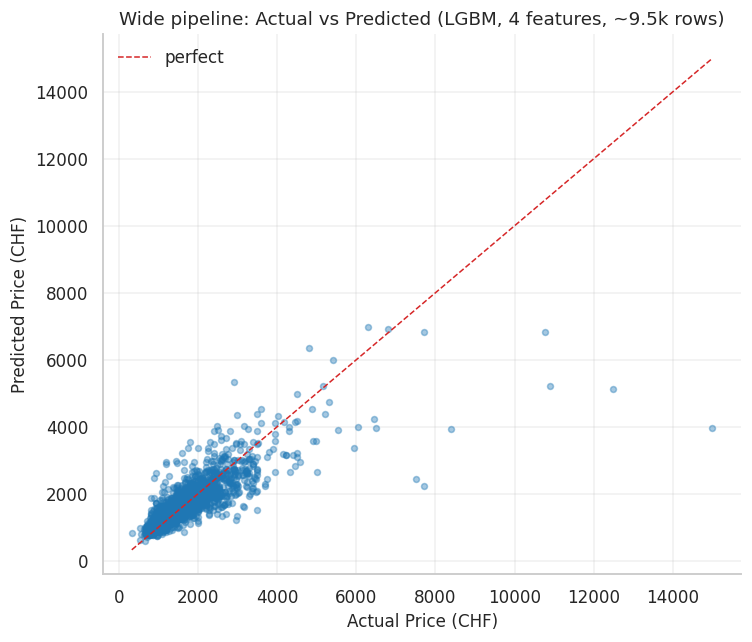

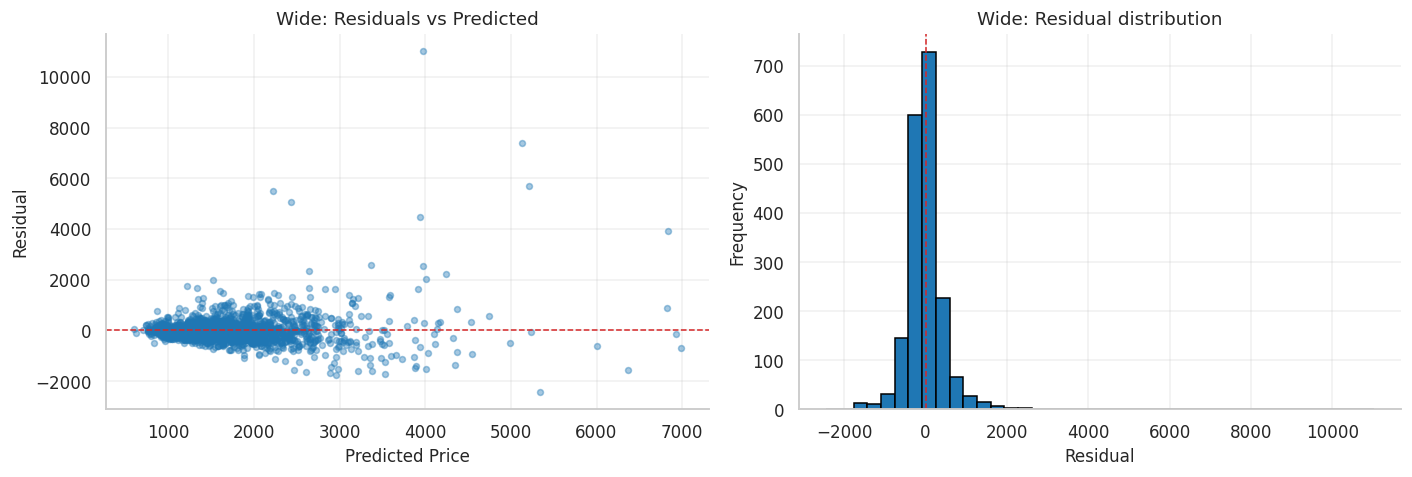

Figures for the final report exported to /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig


In [67]:
# === Additional wide-experiment figures for the final report ===
if HAS_LGBM and lgbm_wide is not None:
    _y_eval_w = eval_wide['price'].values
    _y_pred_w = y_pred_eval_w
    _res_w = _y_eval_w - _y_pred_w

    _FIG_REPORT = Path('../../docs/final-report/fig')
    _FIG_REPORT.mkdir(parents=True, exist_ok=True)

    # Actual vs Predicted
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(_y_eval_w, _y_pred_w, alpha=0.4, s=15)
    _lo = float(min(_y_eval_w.min(), _y_pred_w.min()))
    _hi = float(max(_y_eval_w.max(), _y_pred_w.max()))
    ax.plot([_lo, _hi], [_lo, _hi], color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1, label='perfect')
    ax.set_xlabel('Actual Price (CHF)')
    ax.set_ylabel('Predicted Price (CHF)')
    ax.set_title('Wide pipeline: Actual vs Predicted (LGBM, 4 features, ~9.5k rows)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(_FIG_REPORT / 'wide_actual_vs_predicted.png',
                 dpi=180, bbox_inches='tight')
    plt.show()

    # Residual + histogram
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(_y_pred_w, _res_w, alpha=0.4, s=15)
    axes[0].axhline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
    axes[0].set_xlabel('Predicted Price')
    axes[0].set_ylabel('Residual')
    axes[0].set_title('Wide: Residuals vs Predicted')
    axes[0].grid(True, alpha=0.3)
    axes[1].hist(_res_w, bins=40, edgecolor='black')
    axes[1].axvline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Wide: Residual distribution')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(_FIG_REPORT / 'wide_residuals.png',
                 dpi=180, bbox_inches='tight')
    plt.show()
    print('Figures for the final report exported to', _FIG_REPORT.resolve())


## 27. Export Figures for the Final Report

The final section exports the figures needed for the written report. Keeping the
export in one place makes the report reproducible: run the notebook once, execute
this cell, and the report folder contains the current figures.

In [70]:
# === Export all final-report figures ===
from pathlib import Path
import scipy.stats as stats
from sklearn.inspection import PartialDependenceDisplay

FIG_DIR = Path('../../docs/final-report/fig')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Writing figures to: {FIG_DIR.resolve()}')

def _save(fig, name, dpi=180):
    path = FIG_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'  OK  {name}  ({path.stat().st_size / 1024:.0f} KB)')

# Cache predictions for the exported report figures.
# The report story uses the final GradientBoosting + ALL+geo model.
# If that final model has been created, all diagnostic export plots use it;
# otherwise the code falls back to the preliminary lowest-RMSE benchmark.
if 'final_model' in globals() and 'eval_df_geo' in globals() and 'final_feature_cols' in globals():
    _report_model_name = f'{FINAL_MODEL_NAME} ({FINAL_FEATURE_SET})'
    _report_eval_df = eval_df_geo.copy()
    _y_eval = _report_eval_df[TARGET_COL].values
    _y_pred = final_model.predict(_report_eval_df[final_feature_cols])
else:
    _report_model_name = best_name
    _report_eval_df = eval_df.copy()
    _y_eval = eval_df[TARGET_COL].values
    _y_pred = main_cache[best_name]['eval']

_residuals  = _y_eval - _y_pred

# ------------------------------------------------------------------
# 1) Geo distribution colored by price
# ------------------------------------------------------------------
if {'east', 'north'} <= set(df_for_split.columns):
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(df_for_split['east'], df_for_split['north'],
                    c=df_for_split[TARGET_COL], alpha=0.6, s=10, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Price (CHF)')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_price_map.png')

# ------------------------------------------------------------------
# 2) Price distribution histogram
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df_for_split[TARGET_COL], bins=50, edgecolor='black', color=NOTEBOOK_COLORS['dark'], alpha=0.85)
ax.axvline(df_for_split[TARGET_COL].median(), color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1, label=f"Median = {df_for_split[TARGET_COL].median():.0f} CHF")
ax.set_xlabel('Cold rent (CHF / month)')
ax.set_ylabel('Number of listings')
ax.set_title('Distribution of monthly cold rent')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'price_distribution.png')

# ------------------------------------------------------------------
# 3) Geo clusters
# ------------------------------------------------------------------
if 'train_df_geo' in dir() and 'geo_cluster' in train_df_geo.columns:
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(train_df_geo['east'], train_df_geo['north'],
                    c=train_df_geo['geo_cluster'], cmap='tab20', alpha=0.7, s=10)
    plt.colorbar(sc, ax=ax, label='Geo cluster')
    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'KMeans geo-clusters (k={best_k}) — fitted on train_df only')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(fig, 'geo_clusters.png')

# ------------------------------------------------------------------
# 4) RMSE Train vs Eval bar plot
# ------------------------------------------------------------------
_models_sorted = main_results['Model'].tolist()
_x_pos = np.arange(len(_models_sorted))
_width = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(_x_pos - _width/2, main_results['RMSE Train'], _width, label='RMSE Train')
ax.bar(_x_pos + _width/2, main_results['RMSE Eval'],  _width, label='RMSE Eval')
ax.set_xticks(_x_pos)
ax.set_xticklabels(_models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval per model (FEATURES_ENGINEERED)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'rmse_train_eval.png')

# ------------------------------------------------------------------
# 5) Bootstrap-CI forest plot
# ------------------------------------------------------------------
if 'boot_df' in dir():
    fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(boot_df)))
    _y_pos = np.arange(len(boot_df))
    ax.errorbar(
        boot_df['RMSE_median'], _y_pos,
        xerr=[boot_df['RMSE_median'] - boot_df['RMSE_2.5%'],
              boot_df['RMSE_97.5%']  - boot_df['RMSE_median']],
        fmt='o', capsize=5,
    )
    ax.set_yticks(_y_pos)
    ax.set_yticklabels(boot_df['Model'])
    ax.set_xlabel('RMSE Eval (CHF) with 95% bootstrap CI')
    ax.set_title('Per-model bootstrap CIs — overlapping intervals = not significantly different')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    plt.tight_layout()
    _save(fig, 'bootstrap_ci.png')

# ------------------------------------------------------------------
# 6) Actual vs Predicted scatter
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(_y_eval, _y_pred, alpha=0.4, s=20)
_lo = float(min(_y_eval.min(), _y_pred.min()))
_hi = float(max(_y_eval.max(), _y_pred.max()))
ax.plot([_lo, _hi], [_lo, _hi], color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1, label='perfect prediction')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {_report_model_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'actual_vs_predicted.png')

# ------------------------------------------------------------------
# 7) Residual plot + histogram
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(_y_pred, _residuals, alpha=0.4, s=20)
axes[0].axhline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residuals vs Predicted — {_report_model_name}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(_residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'residuals.png')

# ------------------------------------------------------------------
# 8) Q-Q plot of residuals
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(_residuals, dist='norm', plot=ax)
ax.set_title(f'Q-Q plot of residuals — {_report_model_name}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(fig, 'qq_plot.png')

# ------------------------------------------------------------------
# 9) Error by price band bar plot
# ------------------------------------------------------------------
_eval_band = pd.DataFrame({'actual': _y_eval, 'predicted': _y_pred})
_eval_band['abs_error'] = (_eval_band['actual'] - _eval_band['predicted']).abs()
_eval_band['price_band'] = pd.qcut(_eval_band['actual'], q=4,
                                     labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
                                     duplicates='drop')
_band_stats = _eval_band.groupby('price_band')['abs_error'].agg(['mean', 'median']).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
_x = np.arange(len(_band_stats))
_width = 0.38
ax.bar(_x - _width/2, _band_stats['mean'],   _width, label='Mean abs. error', color=NOTEBOOK_COLORS['dark'])
ax.bar(_x + _width/2, _band_stats['median'], _width, label='Median abs. error', color=NOTEBOOK_COLORS['secondary'], alpha=0.85)
ax.set_xticks(_x)
ax.set_xticklabels(_band_stats.index, rotation=0)
ax.set_ylabel('Absolute error (CHF)')
ax.set_title('Error per price quartile (final model on eval)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_save(fig, 'error_by_priceband.png')

# ------------------------------------------------------------------
# 10) PDP for Top-6 features
# ------------------------------------------------------------------
if 'fi' in dir() and '_pdp_model' in dir():
    _top_features = fi.head(6).index.tolist()
    _X_pdp = train_df[main_features].astype('float64')
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    PartialDependenceDisplay.from_estimator(
        _pdp_model, _X_pdp,
        features=_top_features, ax=axes,
        n_jobs=-1, grid_resolution=40,
    )
    plt.suptitle(f'Partial Dependence Plots — Top 6 features ({_report_model_name})', y=1.02, fontsize=13)
    plt.tight_layout()
    _save(fig, 'pdp_top6.png')

# ------------------------------------------------------------------
# 11) Feature-importance heatmap
# ------------------------------------------------------------------
if 'imp_norm' in dir():
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(imp_norm))))
    sns.heatmap(imp_norm, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax)
    ax.set_title('Feature importance — multi-method comparison')
    plt.tight_layout()
    _save(fig, 'feature_importance_heatmap.png')


# === [auto] additional figures for the final report ===
# Four plots referenced by the final report (.tex) via \autofigure,
# but missing from the original export code. Each block is defensive:
# missing variables / libraries are caught so that an error in
# one block does not kill the other three.

# --- feature_correlation.png --------------------------------------------
try:
    _corr_cols_pref = ['area', 'rooms', 'building_age', 'area_per_room',
                       'east', 'north', 'knn_price_median', 'knn_price_mean']
    _corr_cols = [c for c in _corr_cols_pref if c in train_df.columns]
    if len(_corr_cols) >= 3:
        _corr_df = train_df[_corr_cols + [TARGET_COL]].corr(numeric_only=True)
        _ordered = _corr_df[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).index.tolist()
        _sub = _corr_df.loc[_ordered + [TARGET_COL], _ordered + [TARGET_COL]]
        fig, ax = plt.subplots(figsize=(7.5, 6))
        sns.heatmap(_sub, annot=True, fmt='.2f', cmap='BrBG',
                    center=0, vmin=-1, vmax=1, square=True, ax=ax,
                    cbar_kws={'label': 'Pearson correlation'})
        ax.set_title('Feature correlation with price_cold')
        plt.tight_layout()
        _save(fig, 'feature_correlation.png')
except Exception as _e:
    print(f'  SKIP feature_correlation.png ({_e})')

# --- spatial_residuals.png ----------------------------------------------
try:
    if {'east', 'north'} <= set(_report_eval_df.columns):
        _abs_res = np.abs(_residuals)
        _scale_ref = max(np.percentile(_abs_res, 95), 1.0)
        _sizes = np.clip(8 + (_abs_res / _scale_ref) * 50, 4, 90)
        fig, ax = plt.subplots(figsize=(8.5, 7))
        sc = ax.scatter(_report_eval_df['east'], _report_eval_df['north'],
                        c=_abs_res, s=_sizes, alpha=0.55, cmap='viridis',
                        edgecolors='none')
        plt.colorbar(sc, ax=ax, label='Absolute residual (CHF)')
        ax.set_xlabel('East coordinate (LV95)')
        ax.set_ylabel('North coordinate (LV95)')
        ax.set_title('Geographic distribution of absolute residuals')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        _save(fig, 'spatial_residuals.png')
    else:
        print('  SKIP spatial_residuals.png (_report_eval_df has no east/north)')
except Exception as _e:
    print(f'  SKIP spatial_residuals.png ({_e})')


# --- wide_vs_standard.png and wide_actual_vs_predicted.png ----------------
try:
    if 'comparison' in globals():
        fig, ax = plt.subplots(figsize=(10, 5))
        _x = np.arange(len(comparison))
        _w = 0.38
        ax.bar(_x - _w/2, comparison['RMSE Train'], _w,
               label='RMSE Train', color=NOTEBOOK_COLORS['dark'])
        ax.bar(_x + _w/2, comparison['RMSE Eval'],  _w,
               label='RMSE Eval',  color=NOTEBOOK_COLORS['secondary'])
        for i, gap in enumerate(comparison['Overfit Gap']):
            if pd.notna(gap):
                ax.annotate(f'gap = {gap:.0f}', (_x[i], comparison['RMSE Eval'].iloc[i]),
                            xytext=(0, 6), textcoords='offset points',
                            ha='center', fontsize=10, color=NOTEBOOK_COLORS['neutral'])
        ax.set_xticks(_x)
        ax.set_xticklabels(comparison['Setup'], rotation=0, ha='center', fontsize=10)
        ax.set_ylabel('RMSE (CHF)')
        ax.set_title('Wide pipeline: more data, fewer features')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        _save(fig, 'wide_vs_standard.png')
    else:
        print('  SKIP wide_vs_standard.png (comparison table not available)')
except Exception as _e:
    print(f'  SKIP wide_vs_standard.png ({_e})')

try:
    if 'eval_wide' in globals() and 'y_pred_eval_w' in globals():
        _y_eval_w = eval_wide['price'].values
        _y_pred_w = y_pred_eval_w
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(_y_eval_w, _y_pred_w, alpha=0.4, s=15)
        _lo = float(min(_y_eval_w.min(), _y_pred_w.min()))
        _hi = float(max(_y_eval_w.max(), _y_pred_w.max()))
        ax.plot([_lo, _hi], [_lo, _hi], color=NOTEBOOK_COLORS['reference'], linestyle='--', linewidth=1, label='perfect prediction')
        ax.set_xlabel('Actual Price (CHF)')
        ax.set_ylabel('Predicted Price (CHF)')
        ax.set_title('Wide pipeline: Actual vs Predicted')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        _save(fig, 'wide_actual_vs_predicted.png')
    else:
        print('  SKIP wide_actual_vs_predicted.png (wide predictions not available)')
except Exception as _e:
    print(f'  SKIP wide_actual_vs_predicted.png ({_e})')

print('\nDone. Figures are located in', FIG_DIR.resolve())


Writing figures to: /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig
  OK  geo_price_map.png  (324 KB)
  OK  price_distribution.png  (56 KB)
  OK  geo_clusters.png  (242 KB)
  OK  rmse_train_eval.png  (99 KB)
  OK  bootstrap_ci.png  (75 KB)
  OK  actual_vs_predicted.png  (151 KB)
  OK  residuals.png  (158 KB)
  OK  qq_plot.png  (68 KB)
  OK  error_by_priceband.png  (52 KB)
  OK  pdp_top6.png  (198 KB)
  OK  feature_importance_heatmap.png  (139 KB)
  OK  feature_correlation.png  (149 KB)
  OK  spatial_residuals.png  (193 KB)
  OK  wide_vs_standard.png  (62 KB)
  OK  wide_actual_vs_predicted.png  (115 KB)

Done. Figures are located in /home/sa_linux/code/Elias-Martinelli/dspro1/docs/final-report/fig


## 28. Conclusion and Next Steps

The notebook follows one consistent story: start with a clean modeling table,
compare baseline models, diagnose where they fail, add geography as a central
price signal, and then choose the final model based on robustness rather than
raw eval RMSE alone.

The final model is **GradientBoosting with `ALL+geo`**. This is intentional: it
is slightly less accurate than the most aggressive alternatives on a single eval
split, but it has the better overfitting-gap profile and is therefore the more
defensible final model.

Key findings:

- Tree-based models clearly outperform Ridge for this dataset.
- Location is a major rent driver, and the `geo_cluster` feature improves the modeling story.
- The expensive price segment remains the hardest to predict.
- The largest missing signals are qualitative: floor, view, renovation state, furniture, and interior quality.
- Optional experiments such as tuning, KNN features, regularization, and the wide dataset are useful stress tests, but they do not replace the selected final model.

Next steps for DSPRO2 would be to extract qualitative features from listing text,
connect an additional platform such as Homegate or Immoscout, and retrain the
model with a time-aware validation setup.